# RNN Time-Series Training

## Imports

In [45]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from training import (
    make_final_loaders,
    prepare_cv_data,
    prepare_final_data,
    run_cv_configurations_parallel,
    run_persistence_baseline,
    train_final_model,
)


## Load and prepare all five datasets

In [46]:
PROJECT_ROOT = Path(".")
SPLIT_DIR = PROJECT_ROOT / "splits"
WINDOW_DIR = PROJECT_ROOT / "window-sizes"

RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINT_DIR = PROJECT_ROOT / "models"
PREDICTION_DIR = PROJECT_ROOT / "predictions"
HISTORY_DIR = PROJECT_ROOT / "histories"

FINAL_DIR = PROJECT_ROOT / "final-results"
FINAL_MODEL_DIR = FINAL_DIR / "models"
FINAL_PLOT_DIR = FINAL_DIR / "plots"

for directory in [
    RESULTS_DIR,
    CHECKPOINT_DIR,
    PREDICTION_DIR,
    HISTORY_DIR,
    FINAL_DIR,
    FINAL_MODEL_DIR,
    FINAL_PLOT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

DATASET_COLUMNS = {
    "ds1": "Press_mm_hg",
    "ds2": "bitcoin_close",
    "ds3": "temperature",
    "ds4": "co2",
    "ds5": "wind_velocity",
}

DATASET_LABELS = {
    "ds1": "Atmospheric Pressure",
    "ds2": "Bitcoin BTC/USD",
    "ds3": "Beijing Temperature",
    "ds4": "Mauna Loa CO₂",
    "ds5": "Jena Wind Velocity",
}

development_frames = {}
test_frames = {}
development_values = {}
test_values = {}
window_sizes = {}
prepared_cv = {}

for dataset_name, target_column in DATASET_COLUMNS.items():
    development_path = SPLIT_DIR / dataset_name / "development.csv"
    test_path = SPLIT_DIR / dataset_name / "test.csv"
    window_path = WINDOW_DIR / f"{dataset_name}-windows.json"

    development_frame = pd.read_csv(development_path)
    test_frame = pd.read_csv(test_path)

    if target_column not in development_frame.columns:
        raise KeyError(
            f"{target_column!r} was not found in {development_path}"
        )

    if target_column not in test_frame.columns:
        raise KeyError(
            f"{target_column!r} was not found in {test_path}"
        )

    with open(window_path, "r", encoding="utf-8") as file:
        saved_windows = json.load(file)["window_sizes"]

    development_array = development_frame[
        target_column
    ].to_numpy(dtype=np.float64)

    test_array = test_frame[
        target_column
    ].to_numpy(dtype=np.float64)

    development_frames[dataset_name] = development_frame
    test_frames[dataset_name] = test_frame
    development_values[dataset_name] = development_array
    test_values[dataset_name] = test_array
    window_sizes[dataset_name] = saved_windows

    prepared_cv[dataset_name] = prepare_cv_data(
        dataset_name,
        development_array,
        n_folds=4,
        initial_train_fraction=0.40,
        validation_fraction=0.15,
    )

    print(
        f"{dataset_name}: "
        f"{len(development_array):,} development observations | "
        f"{len(test_array):,} test observations | "
        f"windows={saved_windows}"
    )


ds1: 15,788 development observations | 3,947 test observations | windows=[12, 48, 144, 288]
ds2: 16,000 development observations | 4,000 test observations | windows=[12, 24, 168, 336]
ds3: 17,529 development observations | 4,383 test observations | windows=[12, 84, 360, 1095]
ds4: 13,915 development observations | 3,479 test observations | windows=[30, 180, 365, 730]
ds5: 14,016 development observations | 3,504 test observations | windows=[6, 24, 48, 168]


## Shared training settings and result-selection helpers

In [47]:
ARCHITECTURES = ["elman", "jordan", "multi"]

DEFAULT_HIDDEN_SIZE = 32
DEFAULT_LEARNING_RATE = 1e-3
DEFAULT_WEIGHT_DECAY = 0.0

HIDDEN_SIZES = [8, 16, 32, 64]
LEARNING_RATES = [1e-2, 1e-3, 1e-4]
WEIGHT_DECAYS = [0.0, 1e-5, 1e-4]

BATCH_SIZE = 128
SEED = 42
MAX_EPOCHS = 75
PATIENCE = 8
MIN_DELTA = 1e-4
GRADIENT_CLIP = 1.0

N_JOBS = 4
WORKER_TORCH_THREADS = 1
EXPECTED_FOLDS = 4


def run_parallel_stage(dataset_name, configurations):
    return run_cv_configurations_parallel(
        prepared_cv=prepared_cv[dataset_name],
        configurations=configurations,
        n_jobs=N_JOBS,
        batch_size=BATCH_SIZE,
        seed=SEED,
        activation="tanh",
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        gradient_clip=GRADIENT_CLIP,
        results_csv=RESULTS_DIR / f"{dataset_name}_results.csv",
        checkpoint_dir=CHECKPOINT_DIR,
        prediction_dir=PREDICTION_DIR,
        history_dir=HISTORY_DIR,
        device="cpu",
        shuffle_train=False,
        num_workers=0,
        pin_memory=False,
        mase_lag=1,
        worker_torch_threads=WORKER_TORCH_THREADS,
        verbose=True,
        worker_verbose=False,
        epoch_log_interval=1,
        continue_on_error=False,
    )


def _configuration_mask(results, configuration):
    mask = np.array(
        results["status"].astype(str).eq("completed"),
        dtype=bool,
        copy=True,
    )

    for key, value in configuration.items():
        if key not in results.columns:
            raise KeyError(
                f"Results CSV does not contain required column {key!r}"
            )

        if isinstance(value, (int, float, np.integer, np.floating)):
            numeric = pd.to_numeric(
                results[key],
                errors="coerce",
            ).to_numpy(dtype=float)

            comparison = np.isclose(
                numeric,
                float(value),
                rtol=1e-10,
                atol=1e-12,
                equal_nan=False,
            )
        else:
            comparison = np.array(
                results[key].astype(str).eq(str(value)),
                dtype=bool,
                copy=False,
            )

        mask = np.logical_and(mask, comparison)

    return mask


def summarize_stage(dataset_name, configurations, decision_key):
    results_path = RESULTS_DIR / f"{dataset_name}_results.csv"

    if not results_path.exists():
        raise FileNotFoundError(
            f"No results file exists yet for {dataset_name}: {results_path}"
        )

    results = pd.read_csv(results_path)
    summary_rows = []

    for configuration in configurations:
        subset = results.loc[
            _configuration_mask(results, configuration)
        ].copy()

        if "fold" in subset.columns:
            subset = subset.sort_values("fold")
            subset = subset.drop_duplicates(
                subset=["fold"],
                keep="last",
            )

        completed_folds = len(subset)

        if completed_folds != EXPECTED_FOLDS:
            raise RuntimeError(
                f"{dataset_name} configuration {configuration} has "
                f"{completed_folds}/{EXPECTED_FOLDS} completed folds. "
                "Finish the stage before selecting an optimum."
            )

        summary_rows.append(
            {
                **configuration,
                "folds": completed_folds,
                "mean_val_rmse": subset["val_rmse"].mean(),
                "std_val_rmse": subset["val_rmse"].std(ddof=1),
                "mean_val_mae": subset["val_mae"].mean(),
                "mean_val_mase": subset["val_mase"].mean(),
                "mean_val_pearson_r": subset["val_pearson_r"].mean(),
                "mean_val_r2": subset["val_r2"].mean(),
                "mean_generalization_gap": subset["generalization_gap"].mean(),
                "mean_runtime_seconds": subset["runtime_seconds"].mean(),
                "mean_best_epoch": subset["best_epoch"].mean(),
            }
        )

    summary = pd.DataFrame(summary_rows)

    summary = summary.sort_values(
        ["architecture", "mean_val_rmse"],
        ascending=[True, True],
    ).reset_index(drop=True)

    display_columns = [
        "architecture",
        decision_key,
        "mean_val_rmse",
        "std_val_rmse",
        "mean_val_mae",
        "mean_val_mase",
        "mean_val_pearson_r",
        "mean_val_r2",
        "mean_generalization_gap",
        "mean_runtime_seconds",
        "mean_best_epoch",
    ]

    print(f"\n{dataset_name} results:")
    display(summary[display_columns])

    best_rows = (
        summary.sort_values("mean_val_rmse")
        .groupby("architecture", as_index=False)
        .first()
    )

    decisions = {
        row["architecture"]: row[decision_key]
        for _, row in best_rows.iterrows()
    }

    print(
        f"Optimal {decision_key} for {dataset_name} "
        "(lowest mean validation RMSE):"
    )

    for architecture in ARCHITECTURES:
        selected = decisions[architecture]

        if isinstance(selected, (np.integer, int)):
            selected = int(selected)
        elif decision_key in {"window_size", "hidden_size"}:
            selected = int(selected)
        else:
            selected = float(selected)

        decisions[architecture] = selected
        print(f"  {architecture}: {selected}")

    return summary, decisions


print(
    "Training settings: "
    f"{N_JOBS} parallel workers, "
    f"{WORKER_TORCH_THREADS} PyTorch thread per worker, "
    f"max {MAX_EPOCHS} epochs, patience {PATIENCE}."
)


Training settings: 4 parallel workers, 1 PyTorch thread per worker, max 75 epochs, patience 8.


## Persistence baseline

In [48]:
for dataset_name in DATASET_COLUMNS:
    print(f"\nPersistence baseline: {dataset_name}")

    run_persistence_baseline(
        prepared_cv[dataset_name],
        results_csv=RESULTS_DIR / f"{dataset_name}_results.csv",
        mase_lag=1,
        verbose=True,
    )



Persistence baseline: ds1
[2026-09-25 13:48:26] SKIP ds1_persistence_fold1
[2026-09-25 13:48:26] SKIP ds1_persistence_fold2
[2026-09-25 13:48:26] SKIP ds1_persistence_fold3
[2026-09-25 13:48:26] SKIP ds1_persistence_fold4

Persistence baseline: ds2
[2026-09-25 13:48:26] SKIP ds2_persistence_fold1
[2026-09-25 13:48:26] SKIP ds2_persistence_fold2
[2026-09-25 13:48:26] SKIP ds2_persistence_fold3
[2026-09-25 13:48:26] SKIP ds2_persistence_fold4

Persistence baseline: ds3
[2026-09-25 13:48:26] SKIP ds3_persistence_fold1
[2026-09-25 13:48:26] SKIP ds3_persistence_fold2
[2026-09-25 13:48:26] SKIP ds3_persistence_fold3
[2026-09-25 13:48:26] SKIP ds3_persistence_fold4

Persistence baseline: ds4
[2026-09-25 13:48:26] SKIP ds4_persistence_fold1
[2026-09-25 13:48:26] SKIP ds4_persistence_fold2
[2026-09-25 13:48:26] SKIP ds4_persistence_fold3
[2026-09-25 13:48:26] SKIP ds4_persistence_fold4

Persistence baseline: ds5
[2026-09-25 13:48:26] SKIP ds5_persistence_fold1
[2026-09-25 13:48:26] SKIP ds5_p

# Stage 1 — Window-size search


## Dataset 1 — Atmospheric Pressure

In [49]:
ds1_stage1_configs = [
    {
        "architecture": architecture,
        "window_size": window_size,
        "hidden_size": DEFAULT_HIDDEN_SIZE,
        "learning_rate": DEFAULT_LEARNING_RATE,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for window_size in window_sizes["ds1"]
]

ds1_stage1_run = run_parallel_stage(
    "ds1",
    ds1_stage1_configs,
)

[2026-09-25 13:48:26] SKIP ds1_elman_w12_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w12_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w12_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w12_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w48_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w48_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w48_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w48_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w144_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w144_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w144_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w144_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w288_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:26] SKIP ds1_elman_w288_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13

In [50]:
ds1_stage1_summary, ds1_best_windows = summarize_stage(
    "ds1",
    ds1_stage1_configs,
    decision_key="window_size",
)



ds1 results:


,architecture,window_size,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,12,0.116186,0.029486,0.092100,1.528953,0.999759,0.999393,-0.077498,5.716632,9.75
1,elman,48,0.141804,0.053119,0.115660,1.922924,0.999771,0.999105,-0.190075,11.661035,6.25
2,elman,144,0.177041,0.046297,0.145529,2.409581,0.999680,0.998913,-0.222130,19.380441,4.75
3,elman,288,0.194999,0.121501,0.163259,2.641057,0.999791,0.998641,-0.139164,86.232088,9.50
4,jordan,12,0.144303,0.020348,0.103980,1.735125,0.999671,0.999021,-0.241942,7.560405,23.00
5,jordan,144,0.145465,0.050587,0.099718,1.650537,0.999666,0.999000,-0.171389,62.093978,22.75
6,jordan,48,0.150425,0.045875,0.101449,1.694620,0.999510,0.998785,-0.259330,27.201578,21.25
7,jordan,288,0.155662,0.052691,0.109141,1.798843,0.999663,0.998949,-0.171957,111.955547,21.00
8,multi,288,0.083553,0.025923,0.067205,1.107215,0.999913,0.999745,-0.083668,78.936633,10.50
9,multi,48,0.105112,0.023509,0.078570,1.313474,0.999844,0.999497,-0.096369,15.221537,10.75


Optimal window_size for ds1 (lowest mean validation RMSE):
  elman: 12
  jordan: 12
  multi: 288


## Dataset 2 — Bitcoin BTC/USD

In [51]:
ds2_stage1_configs = [
    {
        "architecture": architecture,
        "window_size": window_size,
        "hidden_size": DEFAULT_HIDDEN_SIZE,
        "learning_rate": DEFAULT_LEARNING_RATE,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for window_size in window_sizes["ds2"]
]

ds2_stage1_run = run_parallel_stage(
    "ds2",
    ds2_stage1_configs,
)

[2026-09-25 13:48:27] SKIP ds2_elman_w12_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w12_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w12_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w12_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w24_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w24_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w24_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w24_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w168_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w168_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w168_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w168_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w336_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:27] SKIP ds2_elman_w336_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13

In [52]:
ds2_stage1_summary, ds2_best_windows = summarize_stage(
    "ds2",
    ds2_stage1_configs,
    decision_key="window_size",
)



ds2 results:


,architecture,window_size,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,336,2831.484369,2482.756456,2180.597456,18.567229,0.988039,0.523001,2301.236012,149.312960,43.50
1,elman,168,3048.759461,2759.847767,2378.153029,20.729325,0.986793,0.353551,2593.824580,121.889359,38.75
2,elman,12,3058.324216,2645.530062,2399.854113,20.553971,0.986739,0.398222,2530.423672,9.980075,33.75
3,elman,24,3076.311774,2757.130363,2435.364677,21.186365,0.987810,0.332696,2639.833788,20.532980,42.00
4,jordan,24,2042.393920,1815.093413,1625.006344,14.279875,0.994343,0.683267,1676.125824,22.957339,53.50
5,jordan,12,2061.072392,1840.674187,1629.518684,14.304026,0.994359,0.682845,1705.666534,17.232242,55.25
6,jordan,168,2159.586509,1914.550121,1694.896029,14.739440,0.994371,0.676153,1798.755384,160.795979,54.25
7,jordan,336,2244.379958,1995.271867,1761.545327,15.233250,0.994352,0.664571,1857.070962,227.928915,50.25
8,multi,168,2670.327447,2373.092314,2034.474755,17.222787,0.988524,0.594854,2156.203705,105.130986,31.75
9,multi,12,2833.779626,2682.189730,2219.103284,19.568844,0.984200,0.385204,2408.281969,11.661350,29.00


Optimal window_size for ds2 (lowest mean validation RMSE):
  elman: 336
  jordan: 24
  multi: 168


## Dataset 3 — Beijing Temperature

In [53]:
ds3_stage1_configs = [
    {
        "architecture": architecture,
        "window_size": window_size,
        "hidden_size": DEFAULT_HIDDEN_SIZE,
        "learning_rate": DEFAULT_LEARNING_RATE,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for window_size in window_sizes["ds3"]
]

ds3_stage1_run = run_parallel_stage(
    "ds3",
    ds3_stage1_configs,
)


[2026-09-25 13:48:27] SKIP ds3_elman_w12_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w12_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w12_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w12_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w84_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w84_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w84_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w84_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w1095_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:27] SKIP ds3_elman_w1095_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 

In [54]:
ds3_stage1_summary, ds3_best_windows = summarize_stage(
    "ds3",
    ds3_stage1_configs,
    decision_key="window_size",
)



ds3 results:


,architecture,window_size,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,360,1.458303,0.058631,1.093153,0.641465,0.988271,0.975879,0.081256,140.513556,20.50
1,elman,1095,1.471770,0.074219,1.111349,0.652303,0.988114,0.974632,0.089587,750.423440,15.25
2,elman,84,1.526753,0.159902,1.154536,0.677426,0.987980,0.973747,0.104110,29.682580,12.50
3,elman,12,1.696278,0.176484,1.291291,0.758308,0.984874,0.964788,0.104779,7.873525,15.00
4,jordan,12,1.959842,0.035390,1.446981,0.849316,0.978133,0.956324,0.082328,7.458888,13.00
5,jordan,84,1.960548,0.035448,1.446893,0.849266,0.978106,0.956292,0.081984,31.450696,12.50
6,jordan,360,1.962111,0.035669,1.447693,0.849740,0.978071,0.956223,0.081598,153.198724,12.50
7,jordan,1095,1.962200,0.034454,1.449150,0.850596,0.978084,0.956210,0.067891,340.752382,13.00
8,multi,1095,1.489883,0.037691,1.123827,0.659693,0.987907,0.974600,0.090822,1012.940169,18.75
9,multi,360,1.531141,0.109366,1.157230,0.679173,0.987935,0.974294,0.105761,146.587579,14.75


Optimal window_size for ds3 (lowest mean validation RMSE):
  elman: 360
  jordan: 12
  multi: 1095


## Dataset 4 — Mauna Loa CO₂

In [55]:
ds4_stage1_configs = [
    {
        "architecture": architecture,
        "window_size": window_size,
        "hidden_size": DEFAULT_HIDDEN_SIZE,
        "learning_rate": DEFAULT_LEARNING_RATE,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for window_size in window_sizes["ds4"]
]

ds4_stage1_run = run_parallel_stage(
    "ds4",
    ds4_stage1_configs,
)


[2026-09-25 13:48:29] SKIP ds4_elman_w30_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w30_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w30_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w30_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w180_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w180_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w180_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w180_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w365_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w365_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w365_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w365_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w730_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:29] SKIP ds4_elman_w730_h32_lr0p001_wd0_fold2_seed42
[2026-09-2

In [56]:
ds4_stage1_summary, ds4_best_windows = summarize_stage(
    "ds4",
    ds4_stage1_configs,
    decision_key="window_size",
)



ds4 results:


,architecture,window_size,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,730,1.083471,0.194318,0.793935,2.657721,0.987035,0.915102,0.549223,1455.030752,40.50
1,elman,365,1.149579,0.387221,0.870330,2.902002,0.987605,0.903411,0.590030,285.308999,36.75
2,elman,180,1.299231,0.322013,0.974210,3.269988,0.984864,0.873336,0.818287,104.621916,33.25
3,elman,30,1.417788,0.223080,1.078279,3.600754,0.984742,0.857208,0.928006,17.963517,28.00
4,jordan,730,0.833092,0.171683,0.622088,2.076606,0.988596,0.950942,0.260054,458.301015,66.00
5,jordan,30,0.833128,0.101635,0.624588,2.089571,0.988490,0.950669,0.238830,32.373425,61.00
6,jordan,365,0.840383,0.110535,0.629245,2.103685,0.988553,0.950034,0.256824,232.263927,63.00
7,jordan,180,0.849412,0.110829,0.637167,2.131785,0.988363,0.948695,0.220587,116.582931,59.75
8,multi,730,1.000075,0.397455,0.755060,2.502260,0.988918,0.928408,0.510284,1266.615926,59.50
9,multi,365,1.076229,0.263169,0.813558,2.706006,0.988576,0.918960,0.619244,407.620577,70.50


Optimal window_size for ds4 (lowest mean validation RMSE):
  elman: 730
  jordan: 730
  multi: 730


## Dataset 5 — Jena Wind Velocity

In [57]:
ds5_stage1_configs = [
    {
        "architecture": architecture,
        "window_size": window_size,
        "hidden_size": DEFAULT_HIDDEN_SIZE,
        "learning_rate": DEFAULT_LEARNING_RATE,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for window_size in window_sizes["ds5"]
]

ds5_stage1_run = run_parallel_stage(
    "ds5",
    ds5_stage1_configs,
)


[2026-09-25 13:48:29] SKIP ds5_elman_w6_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w6_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w6_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w6_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w24_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w24_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w24_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w24_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w48_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w48_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w48_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w48_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w168_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:29] SKIP ds5_elman_w168_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:29] 

In [58]:
ds5_stage1_summary, ds5_best_windows = summarize_stage(
    "ds5",
    ds5_stage1_configs,
    decision_key="window_size",
)



ds5 results:


,architecture,window_size,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,168,0.714139,0.105097,0.487734,0.997823,0.871003,0.755696,0.043630,47.850542,21.75
1,elman,48,0.714934,0.107012,0.488574,0.999656,0.871181,0.755542,0.042792,19.800991,25.75
2,elman,6,0.716280,0.103884,0.488072,0.998458,0.869992,0.754048,0.030674,10.298785,34.50
3,elman,24,0.720049,0.105081,0.492005,1.006642,0.869643,0.751561,0.043305,11.379652,20.00
4,jordan,6,0.715397,0.101906,0.489844,1.001927,0.871518,0.754348,0.025825,10.833461,44.25
5,jordan,168,0.715750,0.101243,0.490409,1.003064,0.871281,0.753955,0.030083,82.107192,43.25
6,jordan,24,0.715834,0.101826,0.490313,1.002884,0.871465,0.754030,0.025950,36.866937,44.25
7,jordan,48,0.715903,0.101573,0.490577,1.003416,0.871502,0.753920,0.027542,34.023021,45.75
8,multi,168,0.706583,0.100217,0.485143,0.992532,0.873102,0.760653,0.035418,74.652200,28.75
9,multi,48,0.708027,0.100869,0.486923,0.996138,0.872592,0.759559,0.033852,34.087938,27.75


Optimal window_size for ds5 (lowest mean validation RMSE):
  elman: 168
  jordan: 6
  multi: 168


# Stage 2 — Hidden-size search


## Dataset 1 — Atmospheric Pressure

In [59]:
ds1_stage2_configs = [
    {
        "architecture": architecture,
        "window_size": ds1_best_windows[architecture],
        "hidden_size": hidden_size,
        "learning_rate": DEFAULT_LEARNING_RATE,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for hidden_size in HIDDEN_SIZES
]

ds1_stage2_run = run_parallel_stage(
    "ds1",
    ds1_stage2_configs,
)


[2026-09-25 13:48:30] SKIP ds1_elman_w12_h8_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h8_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h8_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h8_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h16_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h16_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h16_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h16_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:30] SKIP ds1_elman_w12_h64_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:30] SK

In [60]:
ds1_stage2_summary, ds1_best_hidden_sizes = summarize_stage(
    "ds1",
    ds1_stage2_configs,
    decision_key="hidden_size",
)



ds1 results:


,architecture,hidden_size,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,64,0.085520,0.034902,0.069069,1.144871,0.999945,0.999664,-0.096624,3.595838,5.25
1,elman,32,0.116186,0.029486,0.092100,1.528953,0.999759,0.999393,-0.077498,5.716632,9.75
2,elman,16,0.237727,0.059456,0.186005,3.092274,0.999175,0.997517,-0.282034,3.913464,6.75
3,elman,8,0.401264,0.282492,0.306814,4.945072,0.997344,0.994134,-0.540048,9.860408,15.50
4,jordan,32,0.144303,0.020348,0.103980,1.735125,0.999671,0.999021,-0.241942,7.560405,23.00
5,jordan,64,0.162306,0.129418,0.131145,2.140174,0.999931,0.998848,-0.069091,7.877251,19.00
6,jordan,16,0.164499,0.046550,0.105564,1.741103,0.999614,0.998915,-0.361949,8.266470,18.25
7,jordan,8,0.177102,0.070491,0.126275,2.084131,0.999577,0.998845,-0.380051,7.045340,23.75
8,multi,32,0.083553,0.025923,0.067205,1.107215,0.999913,0.999745,-0.083668,78.936633,10.50
9,multi,16,0.084314,0.035991,0.068229,1.173037,0.999814,0.999573,-0.118798,119.777483,16.25


Optimal hidden_size for ds1 (lowest mean validation RMSE):
  elman: 64
  jordan: 32
  multi: 32


## Dataset 2 — Bitcoin BTC/USD

In [61]:
ds2_stage2_configs = [
    {
        "architecture": architecture,
        "window_size": ds2_best_windows[architecture],
        "hidden_size": hidden_size,
        "learning_rate": DEFAULT_LEARNING_RATE,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for hidden_size in HIDDEN_SIZES
]

ds2_stage2_run = run_parallel_stage(
    "ds2",
    ds2_stage2_configs,
)


[2026-09-25 13:48:30] SKIP ds2_elman_w336_h8_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h8_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h8_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h8_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h16_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h16_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h16_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h16_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:30] SKIP ds2_elman_w336_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds2_elman_w336_h64_lr0p001_wd0_fold2_seed42
[2026-09-2

In [62]:
ds2_stage2_summary, ds2_best_hidden_sizes = summarize_stage(
    "ds2",
    ds2_stage2_configs,
    decision_key="hidden_size",
)



ds2 results:


,architecture,hidden_size,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,64,2298.743111,1094.712655,1917.845067,15.248648,0.993514,0.745689,1386.483723,193.964809,37.50
1,elman,32,2831.484369,2482.756456,2180.597456,18.567229,0.988039,0.523001,2301.236012,149.312960,43.50
2,elman,8,5503.451355,5667.372868,4423.515869,36.606399,0.968813,-0.510177,3768.866478,161.169685,40.50
3,elman,16,6670.273131,6945.555608,5471.495677,49.658258,0.543099,-3.127372,5973.133651,283.597602,51.50
4,jordan,64,1688.296517,1093.867562,1329.255074,10.409265,0.995730,0.890265,1176.087599,31.923435,45.00
5,jordan,32,2042.393920,1815.093413,1625.006344,14.279875,0.994343,0.683267,1676.125824,22.957339,53.50
6,jordan,16,3610.930750,3434.541062,2863.721327,25.140472,0.985900,0.046559,3149.280754,30.263650,52.50
7,jordan,8,4157.254522,4090.538847,3317.424723,29.138208,0.986424,-0.247637,3720.636343,28.765108,66.75
8,multi,32,2670.327447,2373.092314,2034.474755,17.222787,0.988524,0.594854,2156.203705,105.130986,31.75
9,multi,64,3195.568532,1602.787645,2515.373420,20.930958,0.948054,0.397908,323.192866,122.527057,30.00


Optimal hidden_size for ds2 (lowest mean validation RMSE):
  elman: 64
  jordan: 64
  multi: 32


## Dataset 3 — Beijing Temperature

In [63]:
ds3_stage2_configs = [
    {
        "architecture": architecture,
        "window_size": ds3_best_windows[architecture],
        "hidden_size": hidden_size,
        "learning_rate": DEFAULT_LEARNING_RATE,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for hidden_size in HIDDEN_SIZES
]

ds3_stage2_run = run_parallel_stage(
    "ds3",
    ds3_stage2_configs,
)


[2026-09-25 13:48:31] SKIP ds3_elman_w360_h8_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h8_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h8_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h8_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h16_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h16_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h16_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h16_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds3_elman_w360_h64_lr0p001_wd0_fold2_seed42
[2026-09-2

In [64]:
ds3_stage2_summary, ds3_best_hidden_sizes = summarize_stage(
    "ds3",
    ds3_stage2_configs,
    decision_key="hidden_size",
)



ds3 results:


,architecture,hidden_size,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,32,1.458303,0.058631,1.093153,0.641465,0.988271,0.975879,0.081256,140.513556,20.50
1,elman,64,1.510938,0.042692,1.155697,0.678242,0.988222,0.973639,0.096684,85.302828,8.00
2,elman,16,1.751426,0.122425,1.359072,0.797364,0.984082,0.965134,0.091386,144.443561,16.75
3,elman,8,1.853729,0.042965,1.344804,0.789425,0.980614,0.960695,0.093741,209.696786,45.50
4,jordan,32,1.959842,0.035390,1.446981,0.849316,0.978133,0.956324,0.082328,7.458888,13.00
5,jordan,64,1.961245,0.039456,1.444691,0.847957,0.978150,0.956269,0.082010,4.855369,5.00
6,jordan,8,1.962349,0.033441,1.450843,0.851583,0.978061,0.956237,0.078909,12.831509,21.50
7,jordan,16,1.969187,0.032237,1.457874,0.855722,0.977920,0.955882,0.084862,10.294369,21.00
8,multi,32,1.489883,0.037691,1.123827,0.659693,0.987907,0.974600,0.090822,1012.940169,18.75
9,multi,16,1.540453,0.059508,1.155158,0.678027,0.986800,0.972484,0.102274,1140.889135,33.25


Optimal hidden_size for ds3 (lowest mean validation RMSE):
  elman: 32
  jordan: 32
  multi: 32


## Dataset 4 — Mauna Loa CO₂

In [65]:
ds4_stage2_configs = [
    {
        "architecture": architecture,
        "window_size": ds4_best_windows[architecture],
        "hidden_size": hidden_size,
        "learning_rate": DEFAULT_LEARNING_RATE,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for hidden_size in HIDDEN_SIZES
]

ds4_stage2_run = run_parallel_stage(
    "ds4",
    ds4_stage2_configs,
)


[2026-09-25 13:48:31] SKIP ds4_elman_w730_h8_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h8_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h8_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h8_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h16_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h16_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h16_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h16_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds4_elman_w730_h64_lr0p001_wd0_fold2_seed42
[2026-09-2

In [66]:
ds4_stage2_summary, ds4_best_hidden_sizes = summarize_stage(
    "ds4",
    ds4_stage2_configs,
    decision_key="hidden_size",
)



ds4 results:


,architecture,hidden_size,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,64,0.829289,0.179102,0.607332,2.025753,0.988985,0.951663,0.339915,746.339976,20.75
1,elman,32,1.083471,0.194318,0.793935,2.657721,0.987035,0.915102,0.549223,1455.030752,40.50
2,elman,16,1.971162,0.859091,1.368861,4.548422,0.955822,0.712099,1.465197,521.273568,71.50
3,elman,8,2.144067,0.757939,1.630512,5.413755,0.971119,0.669970,1.602134,463.217881,75.00
4,jordan,32,0.833092,0.171683,0.622088,2.076606,0.988596,0.950942,0.260054,458.301015,66.00
5,jordan,64,0.885962,0.323947,0.681939,2.267576,0.989388,0.943411,0.388213,644.032332,67.75
6,jordan,16,1.301929,0.170871,0.971433,3.256187,0.985480,0.877862,0.712574,476.090393,58.50
7,jordan,8,1.830550,0.242071,1.428381,4.777075,0.984659,0.762115,1.334794,434.313582,71.25
8,multi,64,0.708788,0.184503,0.518004,1.732632,0.988282,0.963244,0.069554,667.261339,40.00
9,multi,32,1.000075,0.397455,0.755060,2.502260,0.988918,0.928408,0.510284,1266.615926,59.50


Optimal hidden_size for ds4 (lowest mean validation RMSE):
  elman: 64
  jordan: 32
  multi: 64


## Dataset 5 — Jena Wind Velocity

In [67]:
ds5_stage2_configs = [
    {
        "architecture": architecture,
        "window_size": ds5_best_windows[architecture],
        "hidden_size": hidden_size,
        "learning_rate": DEFAULT_LEARNING_RATE,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for hidden_size in HIDDEN_SIZES
]

ds5_stage2_run = run_parallel_stage(
    "ds5",
    ds5_stage2_configs,
)


[2026-09-25 13:48:31] SKIP ds5_elman_w168_h8_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h8_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h8_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h8_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h16_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h16_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h16_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h16_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds5_elman_w168_h64_lr0p001_wd0_fold2_seed42
[2026-09-2

In [68]:
ds5_stage2_summary, ds5_best_hidden_sizes = summarize_stage(
    "ds5",
    ds5_stage2_configs,
    decision_key="hidden_size",
)



ds5 results:


,architecture,hidden_size,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,64,0.705852,0.100808,0.484475,0.991199,0.874053,0.761012,0.039345,61.763329,13.25
1,elman,32,0.714139,0.105097,0.487734,0.997823,0.871003,0.755696,0.043630,47.850542,21.75
2,elman,16,0.715283,0.103929,0.489568,1.001530,0.871781,0.755128,0.030893,97.784296,48.75
3,elman,8,0.720405,0.109732,0.489790,1.002015,0.870461,0.752119,0.041638,124.183313,74.50
4,jordan,64,0.711028,0.099627,0.487073,0.996302,0.873064,0.757078,0.024394,9.523928,33.75
5,jordan,32,0.715397,0.101906,0.489844,1.001927,0.871518,0.754348,0.025825,10.833461,44.25
6,jordan,16,0.720304,0.108033,0.490398,1.003153,0.870041,0.751695,0.030085,9.494671,50.50
7,jordan,8,0.723021,0.111636,0.490739,1.003934,0.869048,0.750272,0.032847,15.415289,53.50
8,multi,64,0.703483,0.098175,0.486405,0.995087,0.874403,0.762447,0.036025,55.105700,12.25
9,multi,32,0.706583,0.100217,0.485143,0.992532,0.873102,0.760653,0.035418,74.652200,28.75


Optimal hidden_size for ds5 (lowest mean validation RMSE):
  elman: 64
  jordan: 64
  multi: 64


# Stage 3 — Learning-rate search

## Dataset 1 — Atmospheric Pressure

In [69]:
ds1_stage3_configs = [
    {
        "architecture": architecture,
        "window_size": ds1_best_windows[architecture],
        "hidden_size": ds1_best_hidden_sizes[architecture],
        "learning_rate": learning_rate,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for learning_rate in LEARNING_RATES
]

ds1_stage3_run = run_parallel_stage(
    "ds1",
    ds1_stage3_configs,
)


[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p01_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p01_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p01_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p01_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p0001_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p0001_wd0_fold2_seed42
[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p0001_wd0_fold3_seed42
[2026-09-25 13:48:31] SKIP ds1_elman_w12_h64_lr0p0001_wd0_fold4_seed42
[2026-09-25 13:48:31] SKIP ds1_jordan_w12_h32_lr0p01_wd0_fold1_seed42
[2026-09-25 13:48:31] SKIP ds1_jordan_w12_h32_lr0p01_wd0_fold2_seed42
[2026-09-25 13:48:31

In [70]:
ds1_stage3_summary, ds1_best_learning_rates = summarize_stage(
    "ds1",
    ds1_stage3_configs,
    decision_key="learning_rate",
)



ds1 results:


,architecture,learning_rate,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,0.0010,0.085520,0.034902,0.069069,1.144871,0.999945,0.999664,-0.096624,3.595838,5.25
1,elman,0.0001,0.139407,0.028100,0.110049,1.822062,0.999682,0.999256,-0.232116,6.081275,11.00
2,elman,0.0100,1.781268,1.378507,1.512021,26.387171,0.875605,0.722084,-0.661905,5.991216,8.00
3,jordan,0.0100,0.091964,0.014129,0.074533,1.241422,0.999938,0.999685,-0.117227,4.008910,4.25
4,jordan,0.0010,0.144303,0.020348,0.103980,1.735125,0.999671,0.999021,-0.241942,7.560405,23.00
5,jordan,0.0001,0.359259,0.239508,0.297669,4.924046,0.995645,0.989412,-0.471891,23.618279,55.50
6,multi,0.0010,0.083553,0.025923,0.067205,1.107215,0.999913,0.999745,-0.083668,78.936633,10.50
7,multi,0.0001,0.213347,0.113886,0.170402,2.781121,0.999536,0.998379,-0.439549,102.741633,15.50
8,multi,0.0100,0.582571,0.398109,0.432403,7.380557,0.993091,0.965636,-0.616888,149.021149,8.75


Optimal learning_rate for ds1 (lowest mean validation RMSE):
  elman: 0.001
  jordan: 0.01
  multi: 0.001


## Dataset 2 — Bitcoin BTC/USD

In [71]:
ds2_stage3_configs = [
    {
        "architecture": architecture,
        "window_size": ds2_best_windows[architecture],
        "hidden_size": ds2_best_hidden_sizes[architecture],
        "learning_rate": learning_rate,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for learning_rate in LEARNING_RATES
]

ds2_stage3_run = run_parallel_stage(
    "ds2",
    ds2_stage3_configs,
)


[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p01_wd0_fold1_seed42
[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p01_wd0_fold2_seed42
[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p01_wd0_fold3_seed42
[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p01_wd0_fold4_seed42
[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p0001_wd0_fold1_seed42
[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p0001_wd0_fold2_seed42
[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p0001_wd0_fold3_seed42
[2026-09-25 13:48:32] SKIP ds2_elman_w336_h64_lr0p0001_wd0_fold4_seed42
[2026-09-25 13:48:32] SKIP ds2_jordan_w24_h64_lr0p01_wd0_fold1_seed42
[2026-09-25 13:48:32] SKIP ds2_jordan_w24_h64_lr0p01_wd0_fold2_seed42
[2026-09

In [72]:
ds2_stage3_summary, ds2_best_learning_rates = summarize_stage(
    "ds2",
    ds2_stage3_configs,
    decision_key="learning_rate",
)



ds2 results:


,architecture,learning_rate,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,0.0010,2298.743111,1094.712655,1917.845067,15.248648,0.993514,0.745689,1386.483723,193.964809,37.50
1,elman,0.0001,3829.389157,3652.101505,3076.623824,27.462582,0.974000,-0.212905,3424.715903,300.214193,46.75
2,elman,0.0100,10964.917686,8395.703634,8059.886366,53.234817,0.276725,-0.913040,-15394.271479,275.308556,15.75
3,jordan,0.0010,1688.296517,1093.867562,1329.255074,10.409265,0.995730,0.890265,1176.087599,31.923435,45.00
4,jordan,0.0100,2235.862130,1541.320237,1726.247562,13.685512,0.994161,0.801935,317.427284,7.771486,5.00
5,jordan,0.0001,3930.313816,3616.425723,3272.586207,29.037187,0.994272,-0.219363,3344.857622,29.559358,56.50
6,multi,0.0010,2670.327447,2373.092314,2034.474755,17.222787,0.988524,0.594854,2156.203705,105.130986,31.75
7,multi,0.0001,4868.364036,4653.255155,3907.345430,34.456272,0.933140,-0.785096,4298.357259,127.234818,59.50
8,multi,0.0100,5205.566525,2706.956553,4317.556526,29.514951,0.932584,0.431106,-7109.494847,73.431278,9.75


Optimal learning_rate for ds2 (lowest mean validation RMSE):
  elman: 0.001
  jordan: 0.001
  multi: 0.001


## Dataset 3 — Beijing Temperature

In [73]:
ds3_stage3_configs = [
    {
        "architecture": architecture,
        "window_size": ds3_best_windows[architecture],
        "hidden_size": ds3_best_hidden_sizes[architecture],
        "learning_rate": learning_rate,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for learning_rate in LEARNING_RATES
]

ds3_stage3_run = run_parallel_stage(
    "ds3",
    ds3_stage3_configs,
)


[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p01_wd0_fold1_seed42
[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p01_wd0_fold2_seed42
[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p01_wd0_fold3_seed42
[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p01_wd0_fold4_seed42
[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p0001_wd0_fold1_seed42
[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p0001_wd0_fold2_seed42
[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p0001_wd0_fold3_seed42
[2026-09-25 13:48:32] SKIP ds3_elman_w360_h32_lr0p0001_wd0_fold4_seed42
[2026-09-25 13:48:32] SKIP ds3_jordan_w12_h32_lr0p01_wd0_fold1_seed42
[2026-09-25 13:48:32] SKIP ds3_jordan_w12_h32_lr0p01_wd0_fold2_seed42
[2026-09

In [74]:
ds3_stage3_summary, ds3_best_learning_rates = summarize_stage(
    "ds3",
    ds3_stage3_configs,
    decision_key="learning_rate",
)



ds3 results:


,architecture,learning_rate,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,0.0001,1.418067,0.059688,1.055273,0.619525,0.988651,0.977302,0.073726,396.796655,68.75
1,elman,0.0010,1.458303,0.058631,1.093153,0.641465,0.988271,0.975879,0.081256,140.513556,20.50
2,elman,0.0100,2.420121,0.394989,1.906484,1.120029,0.965812,0.925682,-0.050008,158.269745,9.00
3,jordan,0.0010,1.959842,0.035390,1.446981,0.849316,0.978133,0.956324,0.082328,7.458888,13.00
4,jordan,0.0001,1.980975,0.039567,1.468351,0.861944,0.977684,0.955623,0.072448,20.321008,67.75
5,jordan,0.0100,2.128291,0.079347,1.627274,0.954882,0.977304,0.948131,0.114795,2.915164,1.25
6,multi,0.0010,1.489883,0.037691,1.123827,0.659693,0.987907,0.974600,0.090822,1012.940169,18.75
7,multi,0.0001,1.628769,0.227578,1.246827,0.732390,0.984215,0.966670,0.095643,2716.050699,63.50
8,multi,0.0100,2.288123,0.483276,1.727559,1.014107,0.973218,0.941662,-0.244614,448.145607,7.25


Optimal learning_rate for ds3 (lowest mean validation RMSE):
  elman: 0.0001
  jordan: 0.001
  multi: 0.001


## Dataset 4 — Mauna Loa CO₂

In [75]:
ds4_stage3_configs = [
    {
        "architecture": architecture,
        "window_size": ds4_best_windows[architecture],
        "hidden_size": ds4_best_hidden_sizes[architecture],
        "learning_rate": learning_rate,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for learning_rate in LEARNING_RATES
]

ds4_stage3_run = run_parallel_stage(
    "ds4",
    ds4_stage3_configs,
)


[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p01_wd0_fold1_seed42
[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p01_wd0_fold2_seed42
[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p01_wd0_fold3_seed42
[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p01_wd0_fold4_seed42
[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p0001_wd0_fold1_seed42
[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p0001_wd0_fold2_seed42
[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p0001_wd0_fold3_seed42
[2026-09-25 13:48:33] SKIP ds4_elman_w730_h64_lr0p0001_wd0_fold4_seed42
[2026-09-25 13:48:33] SKIP ds4_jordan_w730_h32_lr0p01_wd0_fold1_seed42
[2026-09-25 13:48:33] SKIP ds4_jordan_w730_h32_lr0p01_wd0_fold2_seed42
[2026-

In [76]:
ds4_stage3_summary, ds4_best_learning_rates = summarize_stage(
    "ds4",
    ds4_stage3_configs,
    decision_key="learning_rate",
)



ds4 results:


,architecture,learning_rate,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,0.0010,0.829289,0.179102,0.607332,2.025753,0.988985,0.951663,0.339915,746.339976,20.75
1,elman,0.0001,1.349697,0.343402,0.976648,3.258950,0.982160,0.870083,0.865742,1303.733251,74.00
2,elman,0.0100,2.709024,1.426528,2.249500,7.403793,0.983746,0.453116,-7.211588,442.489606,10.75
3,jordan,0.0010,0.833092,0.171683,0.622088,2.076606,0.988596,0.950942,0.260054,458.301015,66.00
4,jordan,0.0100,1.542049,0.565652,1.242207,4.139146,0.981889,0.825894,0.130741,145.525029,10.75
5,jordan,0.0001,3.553380,0.286726,3.170428,10.614129,0.987078,0.094090,2.900028,526.220670,75.00
6,multi,0.0010,0.708788,0.184503,0.518004,1.732632,0.988282,0.963244,0.069554,667.261339,40.00
7,multi,0.0001,1.961721,0.751553,1.443259,4.803075,0.971568,0.719614,1.404826,3298.066813,74.50
8,multi,0.0100,2.281668,1.767815,1.848947,6.050636,0.985748,0.550758,-4.797984,1088.483835,18.00


Optimal learning_rate for ds4 (lowest mean validation RMSE):
  elman: 0.001
  jordan: 0.001
  multi: 0.001


## Dataset 5 — Jena Wind Velocity

In [77]:
ds5_stage3_configs = [
    {
        "architecture": architecture,
        "window_size": ds5_best_windows[architecture],
        "hidden_size": ds5_best_hidden_sizes[architecture],
        "learning_rate": learning_rate,
        "weight_decay": DEFAULT_WEIGHT_DECAY,
    }
    for architecture in ARCHITECTURES
    for learning_rate in LEARNING_RATES
]

ds5_stage3_run = run_parallel_stage(
    "ds5",
    ds5_stage3_configs,
)


[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p01_wd0_fold1_seed42
[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p01_wd0_fold2_seed42
[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p01_wd0_fold3_seed42
[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p01_wd0_fold4_seed42
[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p0001_wd0_fold1_seed42
[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p0001_wd0_fold2_seed42
[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p0001_wd0_fold3_seed42
[2026-09-25 13:48:33] SKIP ds5_elman_w168_h64_lr0p0001_wd0_fold4_seed42
[2026-09-25 13:48:33] SKIP ds5_jordan_w6_h64_lr0p01_wd0_fold1_seed42
[2026-09-25 13:48:33] SKIP ds5_jordan_w6_h64_lr0p01_wd0_fold2_seed42
[2026-09-2

In [78]:
ds5_stage3_summary, ds5_best_learning_rates = summarize_stage(
    "ds5",
    ds5_stage3_configs,
    decision_key="learning_rate",
)



ds5 results:


,architecture,learning_rate,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,0.0010,0.705852,0.100808,0.484475,0.991199,0.874053,0.761012,0.039345,61.763329,13.25
1,elman,0.0001,0.707465,0.109168,0.483642,0.989562,0.874413,0.761469,0.052246,132.622352,53.00
2,elman,0.0100,0.718043,0.104545,0.492664,1.007866,0.870378,0.752417,0.031004,303.639253,6.25
3,jordan,0.0010,0.711028,0.099627,0.487073,0.996302,0.873064,0.757078,0.024394,9.523928,33.75
4,jordan,0.0001,0.712900,0.102536,0.486641,0.995532,0.871701,0.756327,0.028004,13.483433,66.25
5,jordan,0.0100,0.717187,0.104220,0.489500,1.001384,0.871524,0.753325,0.028648,3.205882,4.00
6,multi,0.0010,0.703483,0.098175,0.486405,0.995087,0.874403,0.762447,0.036025,55.105700,12.25
7,multi,0.0001,0.706190,0.104019,0.484457,0.991147,0.874607,0.761564,0.052970,187.642773,68.00
8,multi,0.0100,0.721174,0.098111,0.510058,1.043736,0.869092,0.749039,0.019670,213.486841,11.75


Optimal learning_rate for ds5 (lowest mean validation RMSE):
  elman: 0.001
  jordan: 0.001
  multi: 0.001


# Stage 4 — Weight-decay search

## Dataset 1 — Atmospheric Pressure

In [79]:
ds1_stage4_configs = [
    {
        "architecture": architecture,
        "window_size": ds1_best_windows[architecture],
        "hidden_size": ds1_best_hidden_sizes[architecture],
        "learning_rate": ds1_best_learning_rates[architecture],
        "weight_decay": weight_decay,
    }
    for architecture in ARCHITECTURES
    for weight_decay in WEIGHT_DECAYS
]

ds1_stage4_run = run_parallel_stage(
    "ds1",
    ds1_stage4_configs,
)


[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd1em05_fold1_seed42
[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd1em05_fold2_seed42
[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd1em05_fold3_seed42
[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd1em05_fold4_seed42
[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd0p0001_fold1_seed42
[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd0p0001_fold2_seed42
[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd0p0001_fold3_seed42
[2026-09-25 13:48:33] SKIP ds1_elman_w12_h64_lr0p001_wd0p0001_fold4_seed42
[2026-09-25 13:48:33] SKIP ds1_jordan_w12_h32_lr0p01_wd0_fold1_seed42
[2026-09-25 13:48:33] SKIP ds1_jordan_w12_h32_lr0p01_w

In [80]:
ds1_stage4_summary, ds1_best_weight_decays = summarize_stage(
    "ds1",
    ds1_stage4_configs,
    decision_key="weight_decay",
)

print("\nFinal selected hyperparameters for ds1:")
for architecture in ARCHITECTURES:
    print(
        f"  {architecture}: "
        f"window={ds1_best_windows[architecture]}, "
        f"hidden={ds1_best_hidden_sizes[architecture]}, "
        f"lr={ds1_best_learning_rates[architecture]}, "
        f"weight_decay={ds1_best_weight_decays[architecture]}"
    )



ds1 results:


,architecture,weight_decay,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,0.00010,0.081967,0.006019,0.064066,1.073579,0.999921,0.999713,-0.095471,3.476080,4.25
1,elman,0.00000,0.085520,0.034902,0.069069,1.144871,0.999945,0.999664,-0.096624,3.595838,5.25
2,elman,0.00001,0.092788,0.035485,0.074459,1.221927,0.999937,0.999704,-0.103218,5.610264,4.50
3,jordan,0.00010,0.088914,0.012282,0.075287,1.255857,0.999932,0.999677,-0.115518,3.835341,4.25
4,jordan,0.00000,0.091964,0.014129,0.074533,1.241422,0.999938,0.999685,-0.117227,4.008910,4.25
5,jordan,0.00001,0.092363,0.013049,0.075127,1.251622,0.999936,0.999676,-0.116873,3.567281,4.25
6,multi,0.00000,0.083553,0.025923,0.067205,1.107215,0.999913,0.999745,-0.083668,78.936633,10.50
7,multi,0.00010,0.090759,0.008844,0.072521,1.212521,0.999911,0.999678,-0.138998,73.886950,9.75
8,multi,0.00001,0.098521,0.027966,0.079567,1.314190,0.999904,0.999674,-0.118412,99.760563,9.25


Optimal weight_decay for ds1 (lowest mean validation RMSE):
  elman: 0.0001
  jordan: 0.0001
  multi: 0.0

Final selected hyperparameters for ds1:
  elman: window=12, hidden=64, lr=0.001, weight_decay=0.0001
  jordan: window=12, hidden=32, lr=0.01, weight_decay=0.0001
  multi: window=288, hidden=32, lr=0.001, weight_decay=0.0


## Dataset 2 — Bitcoin BTC/USD

In [81]:
ds2_stage4_configs = [
    {
        "architecture": architecture,
        "window_size": ds2_best_windows[architecture],
        "hidden_size": ds2_best_hidden_sizes[architecture],
        "learning_rate": ds2_best_learning_rates[architecture],
        "weight_decay": weight_decay,
    }
    for architecture in ARCHITECTURES
    for weight_decay in WEIGHT_DECAYS
]

ds2_stage4_run = run_parallel_stage(
    "ds2",
    ds2_stage4_configs,
)


[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd1em05_fold1_seed42
[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd1em05_fold2_seed42
[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd1em05_fold3_seed42
[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd1em05_fold4_seed42
[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd0p0001_fold1_seed42
[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd0p0001_fold2_seed42
[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd0p0001_fold3_seed42
[2026-09-25 13:48:35] SKIP ds2_elman_w336_h64_lr0p001_wd0p0001_fold4_seed42
[2026-09-25 13:48:35] SKIP ds2_jordan_w24_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:35] SKIP ds2_jordan_w24

In [82]:
ds2_stage4_summary, ds2_best_weight_decays = summarize_stage(
    "ds2",
    ds2_stage4_configs,
    decision_key="weight_decay",
)

print("\nFinal selected hyperparameters for ds2:")
for architecture in ARCHITECTURES:
    print(
        f"  {architecture}: "
        f"window={ds2_best_windows[architecture]}, "
        f"hidden={ds2_best_hidden_sizes[architecture]}, "
        f"lr={ds2_best_learning_rates[architecture]}, "
        f"weight_decay={ds2_best_weight_decays[architecture]}"
    )



ds2 results:


,architecture,weight_decay,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,0.00001,2249.307915,1380.262875,1859.946920,15.099160,0.993420,0.714670,1628.283774,320.366803,39.25
1,elman,0.00000,2298.743111,1094.712655,1917.845067,15.248648,0.993514,0.745689,1386.483723,193.964809,37.50
2,elman,0.00010,3116.207227,1961.060445,2557.908239,19.761210,0.984431,0.654643,1221.123319,106.575860,7.25
3,jordan,0.00000,1688.296517,1093.867562,1329.255074,10.409265,0.995730,0.890265,1176.087599,31.923435,45.00
4,jordan,0.00001,1694.275832,1100.362177,1333.517128,10.434485,0.995732,0.890147,1182.146143,31.583575,45.00
5,jordan,0.00010,1744.940061,1155.906668,1369.279573,10.643398,0.995750,0.889152,1234.082906,25.858679,45.25
6,multi,0.00010,2647.057215,2384.223586,2071.362284,18.061340,0.988132,0.500373,2200.175959,88.170389,32.50
7,multi,0.00000,2670.327447,2373.092314,2034.474755,17.222787,0.988524,0.594854,2156.203705,105.130986,31.75
8,multi,0.00001,2784.523451,2474.438376,2147.803062,18.437775,0.988160,0.517601,2159.158676,103.001252,31.75


Optimal weight_decay for ds2 (lowest mean validation RMSE):
  elman: 1e-05
  jordan: 0.0
  multi: 0.0001

Final selected hyperparameters for ds2:
  elman: window=336, hidden=64, lr=0.001, weight_decay=1e-05
  jordan: window=24, hidden=64, lr=0.001, weight_decay=0.0
  multi: window=168, hidden=32, lr=0.001, weight_decay=0.0001


## Dataset 3 — Beijing Temperature

In [83]:
ds3_stage4_configs = [
    {
        "architecture": architecture,
        "window_size": ds3_best_windows[architecture],
        "hidden_size": ds3_best_hidden_sizes[architecture],
        "learning_rate": ds3_best_learning_rates[architecture],
        "weight_decay": weight_decay,
    }
    for architecture in ARCHITECTURES
    for weight_decay in WEIGHT_DECAYS
]

ds3_stage4_run = run_parallel_stage(
    "ds3",
    ds3_stage4_configs,
)


[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd0_fold1_seed42
[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd0_fold2_seed42
[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd0_fold3_seed42
[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd0_fold4_seed42
[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd1em05_fold1_seed42
[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd1em05_fold2_seed42
[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd1em05_fold3_seed42
[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd1em05_fold4_seed42
[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd0p0001_fold1_seed42
[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd0p0001_fold2_seed42
[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd0p0001_fold3_seed42
[2026-09-25 13:48:36] SKIP ds3_elman_w360_h32_lr0p0001_wd0p0001_fold4_seed42
[2026-09-25 13:48:36] SKIP ds3_jordan_w12_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:36] SKIP ds

In [84]:
ds3_stage4_summary, ds3_best_weight_decays = summarize_stage(
    "ds3",
    ds3_stage4_configs,
    decision_key="weight_decay",
)

print("\nFinal selected hyperparameters for ds3:")
for architecture in ARCHITECTURES:
    print(
        f"  {architecture}: "
        f"window={ds3_best_windows[architecture]}, "
        f"hidden={ds3_best_hidden_sizes[architecture]}, "
        f"lr={ds3_best_learning_rates[architecture]}, "
        f"weight_decay={ds3_best_weight_decays[architecture]}"
    )



ds3 results:


,architecture,weight_decay,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,0.00000,1.418067,0.059688,1.055273,0.619525,0.988651,0.977302,0.073726,396.796655,68.75
1,elman,0.00001,1.418120,0.059728,1.055324,0.619555,0.988650,0.977300,0.073704,416.272095,68.75
2,elman,0.00010,1.418863,0.059833,1.056040,0.619975,0.988636,0.977277,0.073427,413.010606,68.50
3,jordan,0.00010,1.959798,0.035352,1.446966,0.849308,0.978132,0.956326,0.082113,5.402049,12.75
4,jordan,0.00001,1.959835,0.035391,1.446979,0.849315,0.978133,0.956325,0.082317,6.589272,13.00
5,jordan,0.00000,1.959842,0.035390,1.446981,0.849316,0.978133,0.956324,0.082328,7.458888,13.00
6,multi,0.00000,1.489883,0.037691,1.123827,0.659693,0.987907,0.974600,0.090822,1012.940169,18.75
7,multi,0.00001,1.490581,0.038825,1.124580,0.660138,0.987882,0.974577,0.090851,1363.976734,18.00
8,multi,0.00010,1.491791,0.037390,1.126854,0.661470,0.987853,0.974545,0.088264,1105.446434,17.50


Optimal weight_decay for ds3 (lowest mean validation RMSE):
  elman: 0.0
  jordan: 0.0001
  multi: 0.0

Final selected hyperparameters for ds3:
  elman: window=360, hidden=32, lr=0.0001, weight_decay=0.0
  jordan: window=12, hidden=32, lr=0.001, weight_decay=0.0001
  multi: window=1095, hidden=32, lr=0.001, weight_decay=0.0


## Dataset 4 — Mauna Loa CO₂

In [85]:
ds4_stage4_configs = [
    {
        "architecture": architecture,
        "window_size": ds4_best_windows[architecture],
        "hidden_size": ds4_best_hidden_sizes[architecture],
        "learning_rate": ds4_best_learning_rates[architecture],
        "weight_decay": weight_decay,
    }
    for architecture in ARCHITECTURES
    for weight_decay in WEIGHT_DECAYS
]

ds4_stage4_run = run_parallel_stage(
    "ds4",
    ds4_stage4_configs,
)


[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd1em05_fold1_seed42
[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd1em05_fold2_seed42
[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd1em05_fold3_seed42
[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd1em05_fold4_seed42
[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd0p0001_fold1_seed42
[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd0p0001_fold2_seed42
[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd0p0001_fold3_seed42
[2026-09-25 13:48:37] SKIP ds4_elman_w730_h64_lr0p001_wd0p0001_fold4_seed42
[2026-09-25 13:48:37] SKIP ds4_jordan_w730_h32_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:37] SKIP ds4_jordan_w7

In [86]:
ds4_stage4_summary, ds4_best_weight_decays = summarize_stage(
    "ds4",
    ds4_stage4_configs,
    decision_key="weight_decay",
)

print("\nFinal selected hyperparameters for ds4:")
for architecture in ARCHITECTURES:
    print(
        f"  {architecture}: "
        f"window={ds4_best_windows[architecture]}, "
        f"hidden={ds4_best_hidden_sizes[architecture]}, "
        f"lr={ds4_best_learning_rates[architecture]}, "
        f"weight_decay={ds4_best_weight_decays[architecture]}"
    )



ds4 results:


,architecture,weight_decay,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,0.00010,0.824715,0.145148,0.619728,2.068362,0.989890,0.952155,0.343795,1680.319601,35.75
1,elman,0.00000,0.829289,0.179102,0.607332,2.025753,0.988985,0.951663,0.339915,746.339976,20.75
2,elman,0.00001,1.211265,0.393800,0.902371,3.001832,0.980740,0.893846,0.445150,1036.406004,16.75
3,jordan,0.00000,0.833092,0.171683,0.622088,2.076606,0.988596,0.950942,0.260054,458.301015,66.00
4,jordan,0.00001,0.836223,0.174930,0.624788,2.085304,0.988599,0.950593,0.264987,539.636668,65.75
5,jordan,0.00010,0.869273,0.209719,0.653320,2.177112,0.988645,0.946783,0.318655,510.215157,65.75
6,multi,0.00000,0.708788,0.184503,0.518004,1.732632,0.988282,0.963244,0.069554,667.261339,40.00
7,multi,0.00001,0.777657,0.135005,0.567555,1.901526,0.989105,0.956412,0.142091,812.411733,32.25
8,multi,0.00010,0.941665,0.230405,0.712764,2.384084,0.987699,0.935264,0.202949,1103.493097,24.50


Optimal weight_decay for ds4 (lowest mean validation RMSE):
  elman: 0.0001
  jordan: 0.0
  multi: 0.0

Final selected hyperparameters for ds4:
  elman: window=730, hidden=64, lr=0.001, weight_decay=0.0001
  jordan: window=730, hidden=32, lr=0.001, weight_decay=0.0
  multi: window=730, hidden=64, lr=0.001, weight_decay=0.0


## Dataset 5 — Jena Wind Velocity

In [87]:
ds5_stage4_configs = [
    {
        "architecture": architecture,
        "window_size": ds5_best_windows[architecture],
        "hidden_size": ds5_best_hidden_sizes[architecture],
        "learning_rate": ds5_best_learning_rates[architecture],
        "weight_decay": weight_decay,
    }
    for architecture in ARCHITECTURES
    for weight_decay in WEIGHT_DECAYS
]

ds5_stage4_run = run_parallel_stage(
    "ds5",
    ds5_stage4_configs,
)


[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd0_fold2_seed42
[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd0_fold3_seed42
[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd0_fold4_seed42
[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd1em05_fold1_seed42
[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd1em05_fold2_seed42
[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd1em05_fold3_seed42
[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd1em05_fold4_seed42
[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd0p0001_fold1_seed42
[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd0p0001_fold2_seed42
[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd0p0001_fold3_seed42
[2026-09-25 13:48:38] SKIP ds5_elman_w168_h64_lr0p001_wd0p0001_fold4_seed42
[2026-09-25 13:48:38] SKIP ds5_jordan_w6_h64_lr0p001_wd0_fold1_seed42
[2026-09-25 13:48:38] SKIP ds5_jordan_w6_h

In [88]:
ds5_stage4_summary, ds5_best_weight_decays = summarize_stage(
    "ds5",
    ds5_stage4_configs,
    decision_key="weight_decay",
)

print("\nFinal selected hyperparameters for ds5:")
for architecture in ARCHITECTURES:
    print(
        f"  {architecture}: "
        f"window={ds5_best_windows[architecture]}, "
        f"hidden={ds5_best_hidden_sizes[architecture]}, "
        f"lr={ds5_best_learning_rates[architecture]}, "
        f"weight_decay={ds5_best_weight_decays[architecture]}"
    )



ds5 results:


,architecture,weight_decay,mean_val_rmse,std_val_rmse,mean_val_mae,mean_val_mase,mean_val_pearson_r,mean_val_r2,mean_generalization_gap,mean_runtime_seconds,mean_best_epoch
0,elman,0.00000,0.705852,0.100808,0.484475,0.991199,0.874053,0.761012,0.039345,61.763329,13.25
1,elman,0.00001,0.707439,0.101557,0.483448,0.989144,0.874205,0.760094,0.040391,47.751511,11.75
2,elman,0.00010,0.707515,0.099176,0.481003,0.984031,0.873405,0.759659,0.029239,51.594397,7.00
3,jordan,0.00000,0.711028,0.099627,0.487073,0.996302,0.873064,0.757078,0.024394,9.523928,33.75
4,jordan,0.00001,0.711071,0.099573,0.487155,0.996466,0.873060,0.757040,0.024344,8.920755,32.25
5,jordan,0.00010,0.711231,0.099635,0.487214,0.996585,0.873031,0.756926,0.024408,8.203811,30.50
6,multi,0.00000,0.703483,0.098175,0.486405,0.995087,0.874403,0.762447,0.036025,55.105700,12.25
7,multi,0.00001,0.704905,0.099325,0.487959,0.998336,0.873981,0.761674,0.037580,67.535537,12.25
8,multi,0.00010,0.705774,0.100448,0.487390,0.997198,0.873990,0.761311,0.039770,61.868554,11.25


Optimal weight_decay for ds5 (lowest mean validation RMSE):
  elman: 0.0
  jordan: 0.0
  multi: 0.0

Final selected hyperparameters for ds5:
  elman: window=168, hidden=64, lr=0.001, weight_decay=0.0
  jordan: window=6, hidden=64, lr=0.001, weight_decay=0.0
  multi: window=168, hidden=64, lr=0.001, weight_decay=0.0


# Train on full development data and evaluate on the untouched test data

## Final-evaluation helpers

In [89]:
FINAL_SEED = 42

final_models = {}
final_predictions = {}
final_test_results = []
final_epoch_choices = []


def final_hyperparameters_for_dataset(dataset_name):
    best_windows = globals()[f"{dataset_name}_best_windows"]
    best_hidden_sizes = globals()[f"{dataset_name}_best_hidden_sizes"]
    best_learning_rates = globals()[f"{dataset_name}_best_learning_rates"]
    best_weight_decays = globals()[f"{dataset_name}_best_weight_decays"]

    return {
        architecture: {
            "window_size": int(best_windows[architecture]),
            "hidden_size": int(best_hidden_sizes[architecture]),
            "learning_rate": float(best_learning_rates[architecture]),
            "weight_decay": float(best_weight_decays[architecture]),
        }
        for architecture in ARCHITECTURES
    }


def selected_cv_rows(dataset_name, architecture, configuration):
    path = RESULTS_DIR / f"{dataset_name}_results.csv"
    results = pd.read_csv(path)

    mask = (
        results["status"].astype(str).eq("completed")
        & results["architecture"].astype(str).eq(architecture)
        & np.isclose(
            pd.to_numeric(
                results["window_size"],
                errors="coerce",
            ),
            configuration["window_size"],
        )
        & np.isclose(
            pd.to_numeric(
                results["hidden_size"],
                errors="coerce",
            ),
            configuration["hidden_size"],
        )
        & np.isclose(
            pd.to_numeric(
                results["learning_rate"],
                errors="coerce",
            ),
            configuration["learning_rate"],
        )
        & np.isclose(
            pd.to_numeric(
                results["weight_decay"],
                errors="coerce",
            ),
            configuration["weight_decay"],
        )
    )

    selected = results.loc[mask].copy()

    if "fold" in selected.columns:
        selected = (
            selected.sort_values("fold")
            .drop_duplicates(subset=["fold"], keep="last")
        )

    if len(selected) != EXPECTED_FOLDS:
        raise RuntimeError(
            f"{dataset_name} {architecture}: expected "
            f"{EXPECTED_FOLDS} completed CV folds for the final "
            f"configuration, found {len(selected)}."
        )

    return selected.sort_values("fold")


def choose_final_epochs(dataset_name, architecture, configuration):
    selected = selected_cv_rows(
        dataset_name,
        architecture,
        configuration,
    )

    best_epochs = pd.to_numeric(
        selected["best_epoch"],
        errors="raise",
    ).to_numpy(dtype=float)

    median_best_epoch = float(np.median(best_epochs))

    # Round halves upward rather than relying on Python's banker's rounding.
    final_epochs = max(
        1,
        int(np.floor(median_best_epoch + 0.5)),
    )

    return final_epochs, best_epochs


def calculate_metrics(y_true, y_pred, mase_scale=None):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    error = y_pred - y_true
    absolute_error = np.abs(error)

    mse = float(np.mean(error ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(absolute_error))
    mean_error = float(np.mean(error))
    median_absolute_error = float(np.median(absolute_error))

    denominator = float(
        np.sum(
            (y_true - np.mean(y_true)) ** 2
        )
    )

    if denominator > 0:
        r2 = float(
            1.0
            - np.sum(error ** 2)
            / denominator
        )
    else:
        r2 = float("nan")

    true_std = float(np.std(y_true))
    pred_std = float(np.std(y_pred))

    if true_std > 0 and pred_std > 0:
        pearson_r = float(
            np.corrcoef(y_true, y_pred)[0, 1]
        )
    else:
        pearson_r = float("nan")

    metrics = {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "r2": r2,
        "mean_error": mean_error,
        "median_absolute_error": median_absolute_error,
    }

    if mase_scale is not None:
        metrics["mase"] = (
            float(mae / mase_scale)
            if mase_scale > 0
            else float("nan")
        )

    return metrics


def mase_scale_from_development(values):
    values = np.asarray(values, dtype=np.float64)

    return float(
        np.mean(
            np.abs(
                values[1:]
                - values[:-1]
            )
        )
    )


def collect_test_predictions(
    model,
    prepared_final,
    window_size,
    batch_size=BATCH_SIZE,
):
    _, test_loader = make_final_loaders(
        prepared=prepared_final,
        window_size=window_size,
        batch_size=batch_size,
        shuffle_train=False,
        num_workers=0,
        pin_memory=False,
    )

    device = next(model.parameters()).device

    predictions_scaled = []
    targets_scaled = []

    model.eval()

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            prediction = model(x_batch)

            predictions_scaled.append(
                prediction.detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )

            targets_scaled.append(
                y_batch.detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )

    predictions_scaled = np.concatenate(
        predictions_scaled
    )

    targets_scaled = np.concatenate(
        targets_scaled
    )

    y_pred = prepared_final.scaler.inverse_transform(
        predictions_scaled.reshape(-1, 1)
    ).reshape(-1)

    y_true = prepared_final.scaler.inverse_transform(
        targets_scaled.reshape(-1, 1)
    ).reshape(-1)

    return y_true, y_pred


def persistence_test_predictions(dataset_name):
    development = development_values[dataset_name]
    test = test_values[dataset_name]

    previous = np.concatenate(
        [
            development[-1:],
            test[:-1],
        ]
    )

    return test.copy(), previous


def timestamp_axis(frame):
    if "date" not in frame.columns:
        return np.arange(len(frame))

    parsed = pd.to_datetime(
        frame["date"],
        errors="coerce",
    )

    if parsed.notna().all():
        return parsed

    return np.arange(len(frame))


def train_and_evaluate_dataset(dataset_name):
    print(
        "\n"
        + "=" * 80
        + f"\nFINAL TRAINING: {dataset_name} — "
        + DATASET_LABELS[dataset_name]
        + "\n"
        + "=" * 80
    )

    configurations = final_hyperparameters_for_dataset(
        dataset_name
    )

    prepared_final = prepare_final_data(
        dataset_name,
        development_values[dataset_name],
        test_values[dataset_name],
    )

    final_models[dataset_name] = {}
    final_predictions[dataset_name] = {}

    mase_scale = mase_scale_from_development(
        development_values[dataset_name]
    )

    dataset_rows = []

    # Persistence is evaluated only as a benchmark.
    persistence_true, persistence_pred = (
        persistence_test_predictions(dataset_name)
    )

    persistence_metrics = calculate_metrics(
        persistence_true,
        persistence_pred,
        mase_scale,
    )

    persistence_row = {
        "dataset": dataset_name,
        "model": "persistence",
        "architecture": "persistence",
        "window_size": 1,
        "hidden_size": np.nan,
        "learning_rate": np.nan,
        "weight_decay": np.nan,
        "epochs": 0,
        "seed": np.nan,
        "test_mse": persistence_metrics["mse"],
        "test_rmse": persistence_metrics["rmse"],
        "test_mae": persistence_metrics["mae"],
        "test_mase": persistence_metrics["mase"],
        "test_pearson_r": persistence_metrics["pearson_r"],
        "test_r2": persistence_metrics["r2"],
        "test_mean_error": persistence_metrics["mean_error"],
        "test_median_absolute_error": (
            persistence_metrics["median_absolute_error"]
        ),
        "runtime_seconds": 0.0,
    }

    dataset_rows.append(persistence_row)

    for architecture in ARCHITECTURES:
        configuration = configurations[architecture]

        epochs, cv_best_epochs = choose_final_epochs(
            dataset_name,
            architecture,
            configuration,
        )

        selected_cv = selected_cv_rows(
            dataset_name,
            architecture,
            configuration,
        )

        cv_mean_rmse = float(
            selected_cv["val_rmse"].mean()
        )

        cv_std_rmse = float(
            selected_cv["val_rmse"].std(ddof=1)
        )

        final_epoch_choices.append(
            {
                "dataset": dataset_name,
                "architecture": architecture,
                **configuration,
                "cv_best_epochs": ", ".join(
                    str(int(value))
                    for value in cv_best_epochs
                ),
                "median_cv_best_epoch": float(
                    np.median(cv_best_epochs)
                ),
                "final_epochs": epochs,
                "cv_mean_val_rmse": cv_mean_rmse,
                "cv_std_val_rmse": cv_std_rmse,
            }
        )

        print(
            f"\n{architecture.upper()} | "
            f"window={configuration['window_size']} | "
            f"hidden={configuration['hidden_size']} | "
            f"lr={configuration['learning_rate']} | "
            f"wd={configuration['weight_decay']} | "
            f"CV best epochs={list(cv_best_epochs.astype(int))} | "
            f"final epochs={epochs}"
        )

        checkpoint_path = (
            FINAL_MODEL_DIR
            / dataset_name
            / f"{architecture}.pt"
        )

        checkpoint_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        training_start = time.perf_counter()

        model, _ = train_final_model(
            prepared=prepared_final,
            architecture=architecture,
            window_size=configuration["window_size"],
            hidden_size=configuration["hidden_size"],
            learning_rate=configuration["learning_rate"],
            weight_decay=configuration["weight_decay"],
            epochs=epochs,
            batch_size=BATCH_SIZE,
            seed=FINAL_SEED,
            activation="tanh",
            gradient_clip=GRADIENT_CLIP,
            device="cpu",
            checkpoint_path=checkpoint_path,
            shuffle_train=False,
            num_workers=0,
            pin_memory=False,
            mase_lag=1,
            verbose=True,
            epoch_log_interval=max(1, epochs // 10),
        )

        runtime_seconds = (
            time.perf_counter()
            - training_start
        )

        y_true, y_pred = collect_test_predictions(
            model=model,
            prepared_final=prepared_final,
            window_size=configuration["window_size"],
        )

        metrics = calculate_metrics(
            y_true,
            y_pred,
            mase_scale,
        )

        final_models[dataset_name][architecture] = model
        final_predictions[dataset_name][architecture] = {
            "y_true": y_true,
            "y_pred": y_pred,
        }

        prediction_path = (
            FINAL_DIR
            / f"{dataset_name}_{architecture}_test_predictions.npz"
        )

        np.savez_compressed(
            prediction_path,
            y_true=y_true,
            y_pred=y_pred,
        )

        row = {
            "dataset": dataset_name,
            "model": architecture,
            "architecture": architecture,
            **configuration,
            "epochs": epochs,
            "seed": FINAL_SEED,
            "cv_mean_val_rmse": cv_mean_rmse,
            "cv_std_val_rmse": cv_std_rmse,
            "test_mse": metrics["mse"],
            "test_rmse": metrics["rmse"],
            "test_mae": metrics["mae"],
            "test_mase": metrics["mase"],
            "test_pearson_r": metrics["pearson_r"],
            "test_r2": metrics["r2"],
            "test_mean_error": metrics["mean_error"],
            "test_median_absolute_error": (
                metrics["median_absolute_error"]
            ),
            "runtime_seconds": runtime_seconds,
            "checkpoint_path": str(checkpoint_path),
            "prediction_path": str(prediction_path),
        }

        dataset_rows.append(row)

        print(
            f"{architecture.upper()} test RMSE="
            f"{metrics['rmse']:.6g} | "
            f"MAE={metrics['mae']:.6g} | "
            f"MASE={metrics['mase']:.6g} | "
            f"R²={metrics['r2']:.6g}"
        )

    # Replace any previous in-memory rows for this dataset, then persist
    # progress immediately so a later interruption does not lose completed
    # final evaluations.
    final_test_results[:] = [
        row
        for row in final_test_results
        if row.get("dataset") != dataset_name
    ]

    final_test_results.extend(dataset_rows)

    dataset_table = pd.DataFrame(dataset_rows)

    pd.DataFrame(final_test_results).to_csv(
        FINAL_DIR / "final_test_results_partial.csv",
        index=False,
    )

    display_columns = [
        "model",
        "test_rmse",
        "test_mae",
        "test_mase",
        "test_pearson_r",
        "test_r2",
        "test_mean_error",
        "runtime_seconds",
    ]

    print(
        f"\nTest results for {dataset_name}:"
    )

    display(
        dataset_table[display_columns]
        .sort_values("test_rmse")
        .reset_index(drop=True)
    )

    rnn_rows = dataset_table[
        dataset_table["architecture"].isin(
            ARCHITECTURES
        )
    ]

    best_rnn_row = rnn_rows.loc[
        rnn_rows["test_rmse"].idxmin()
    ]

    best_overall_row = dataset_table.loc[
        dataset_table["test_rmse"].idxmin()
    ]

    print(
        f"Best RNN on the untouched test set: "
        f"{best_rnn_row['architecture']} "
        f"(RMSE={best_rnn_row['test_rmse']:.6g})"
    )

    print(
        f"Best overall including persistence: "
        f"{best_overall_row['architecture']} "
        f"(RMSE={best_overall_row['test_rmse']:.6g})"
    )

    return dataset_table


def plot_full_series(dataset_name):
    target_column = DATASET_COLUMNS[dataset_name]

    development_frame = development_frames[dataset_name]
    test_frame = test_frames[dataset_name]

    development_x = timestamp_axis(
        development_frame
    )

    test_x = timestamp_axis(
        test_frame
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        development_x,
        development_frame[target_column],
        label="Development",
    )

    plt.plot(
        test_x,
        test_frame[target_column],
        label="Test",
    )

    if "date" in test_frame.columns:
        test_dates = pd.to_datetime(
            test_frame["date"],
            errors="coerce",
        )

        if test_dates.notna().all():
            plt.axvline(
                test_dates.iloc[0],
                linestyle="--",
                label="Test boundary",
            )

    plt.title(
        f"{DATASET_LABELS[dataset_name]} — "
        "full development and test series"
    )

    plt.xlabel("Time")
    plt.ylabel(target_column)
    plt.legend()
    plt.tight_layout()

    path = (
        FINAL_PLOT_DIR
        / f"{dataset_name}_full_series.png"
    )

    plt.savefig(
        path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


def plot_test_predictions(dataset_name):
    test_x = timestamp_axis(
        test_frames[dataset_name]
    )

    actual = test_values[dataset_name]

    plt.figure(figsize=(14, 5))

    plt.plot(
        test_x,
        actual,
        label="Actual",
        linewidth=2,
    )

    for architecture in ARCHITECTURES:
        prediction = final_predictions[
            dataset_name
        ][architecture]["y_pred"]

        plt.plot(
            test_x,
            prediction,
            label=("Multi-Recurrent" if architecture == "multi" else architecture.capitalize()),
        )

    plt.title(
        f"{DATASET_LABELS[dataset_name]} — "
        "untouched test predictions"
    )

    plt.xlabel("Time")
    plt.ylabel(DATASET_COLUMNS[dataset_name])
    plt.legend()
    plt.tight_layout()

    path = (
        FINAL_PLOT_DIR
        / f"{dataset_name}_test_predictions.png"
    )

    plt.savefig(
        path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


## Dataset 1 — Atmospheric Pressure


FINAL TRAINING: ds1 — Atmospheric Pressure

ELMAN | window=12 | hidden=64 | lr=0.001 | wd=0.0001 | CV best epochs=[np.int64(6), np.int64(3), np.int64(5), np.int64(3)] | final epochs=4
[2026-09-25 13:49:00] final epoch 1/4 | train_scaled_mse=0.0370392
[2026-09-25 13:49:03] final epoch 2/4 | train_scaled_mse=0.00204416
[2026-09-25 13:49:06] final epoch 3/4 | train_scaled_mse=0.00069212
[2026-09-25 13:49:08] final epoch 4/4 | train_scaled_mse=0.00143675
ELMAN test RMSE=0.223585 | MAE=0.162775 | MASE=3.11006 | R²=0.998411

JORDAN | window=12 | hidden=32 | lr=0.01 | wd=0.0001 | CV best epochs=[np.int64(5), np.int64(5), np.int64(2), np.int64(5)] | final epochs=5
[2026-09-25 13:49:13] final epoch 1/5 | train_scaled_mse=0.0719533
[2026-09-25 13:49:14] final epoch 2/5 | train_scaled_mse=0.00299196
[2026-09-25 13:49:15] final epoch 3/5 | train_scaled_mse=0.000764657
[2026-09-25 13:49:17] final epoch 4/5 | train_scaled_mse=0.000602784
[2026-09-25 13:49:18] final epoch 5/5 | train_scaled_mse=0.00

,model,test_rmse,test_mae,test_mase,test_pearson_r,test_r2,test_mean_error,runtime_seconds
0,multi,0.037988,0.027547,0.526333,0.999978,0.999954,-0.003271,1454.704973
1,persistence,0.048885,0.037809,0.722401,0.999962,0.999924,0.000752,0.000000
2,jordan,0.094995,0.062126,1.187000,0.999955,0.999713,-0.044642,8.351482
3,elman,0.223585,0.162775,3.110057,0.999920,0.998411,-0.084366,25.698542


Best RNN on the untouched test set: multi (RMSE=0.0379877)
Best overall including persistence: multi (RMSE=0.0379877)


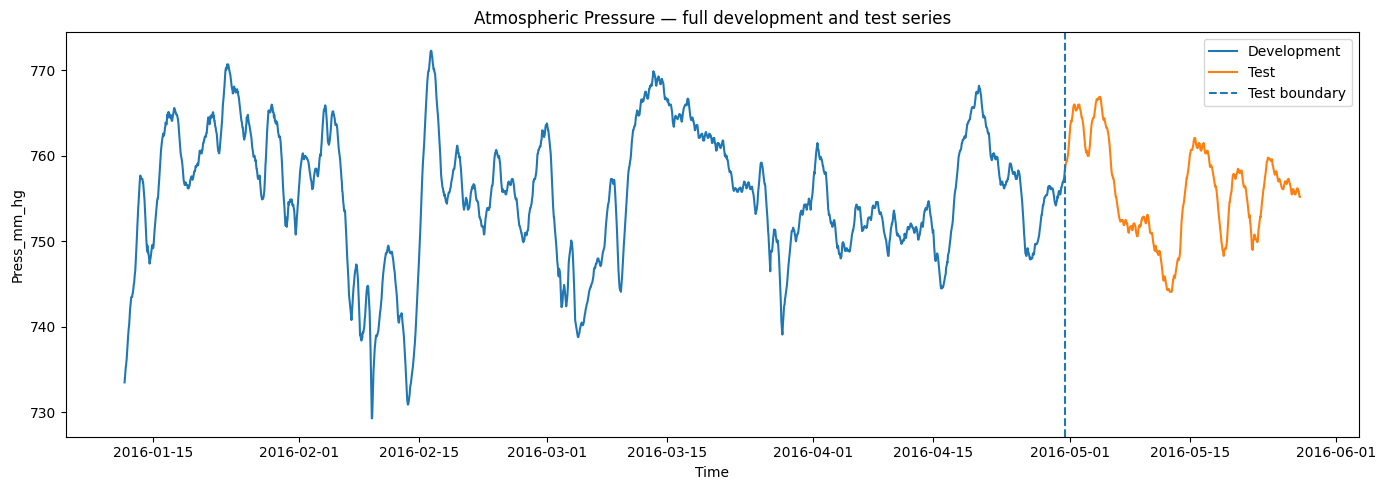

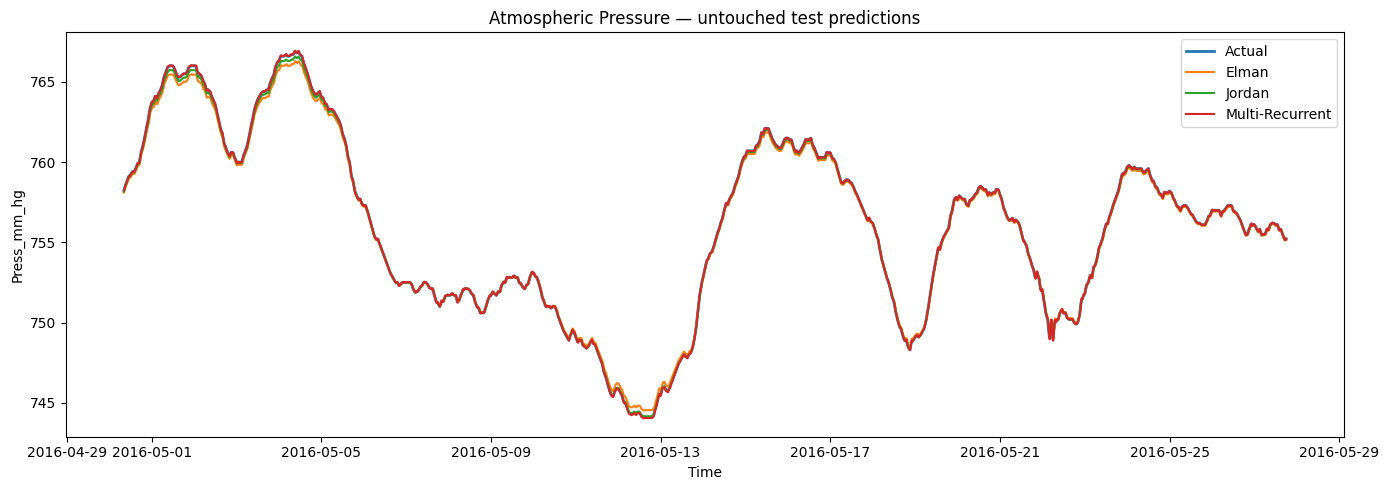

In [90]:
ds1_final_table = train_and_evaluate_dataset("ds1")

plot_full_series("ds1")
plot_test_predictions("ds1")


## Dataset 2 — Bitcoin BTC/USD


FINAL TRAINING: ds2 — Bitcoin BTC/USD

ELMAN | window=336 | hidden=64 | lr=0.001 | wd=1e-05 | CV best epochs=[np.int64(53), np.int64(16), np.int64(74), np.int64(14)] | final epochs=35
[2026-09-25 14:14:08] final epoch 1/35 | train_scaled_mse=0.0282605
[2026-09-25 14:15:09] final epoch 3/35 | train_scaled_mse=0.00498383
[2026-09-25 14:16:46] final epoch 6/35 | train_scaled_mse=0.00139888
[2026-09-25 14:18:17] final epoch 9/35 | train_scaled_mse=0.000940729
[2026-09-25 14:19:38] final epoch 12/35 | train_scaled_mse=0.000810496
[2026-09-25 14:20:58] final epoch 15/35 | train_scaled_mse=0.000736488
[2026-09-25 14:22:14] final epoch 18/35 | train_scaled_mse=0.00068134
[2026-09-25 14:23:30] final epoch 21/35 | train_scaled_mse=0.000636555
[2026-09-25 14:24:47] final epoch 24/35 | train_scaled_mse=0.000599853
[2026-09-25 14:26:06] final epoch 27/35 | train_scaled_mse=0.000570536
[2026-09-25 14:27:24] final epoch 30/35 | train_scaled_mse=0.000548259
[2026-09-25 14:28:48] final epoch 33/35 | t

,model,test_rmse,test_mae,test_mase,test_pearson_r,test_r2,test_mean_error,runtime_seconds
0,persistence,403.632646,272.753750,1.312302,0.999324,0.998647,-7.989750,0.000000
1,elman,3118.769739,2820.470697,13.570146,0.998828,0.919211,-2809.961400,984.405419
2,jordan,3689.965910,3252.907764,15.650733,0.998261,0.886908,-3215.140369,84.357508
3,multi,4687.787945,4115.150459,19.799245,0.997901,0.817474,-4070.205029,937.183617


Best RNN on the untouched test set: elman (RMSE=3118.77)
Best overall including persistence: persistence (RMSE=403.633)


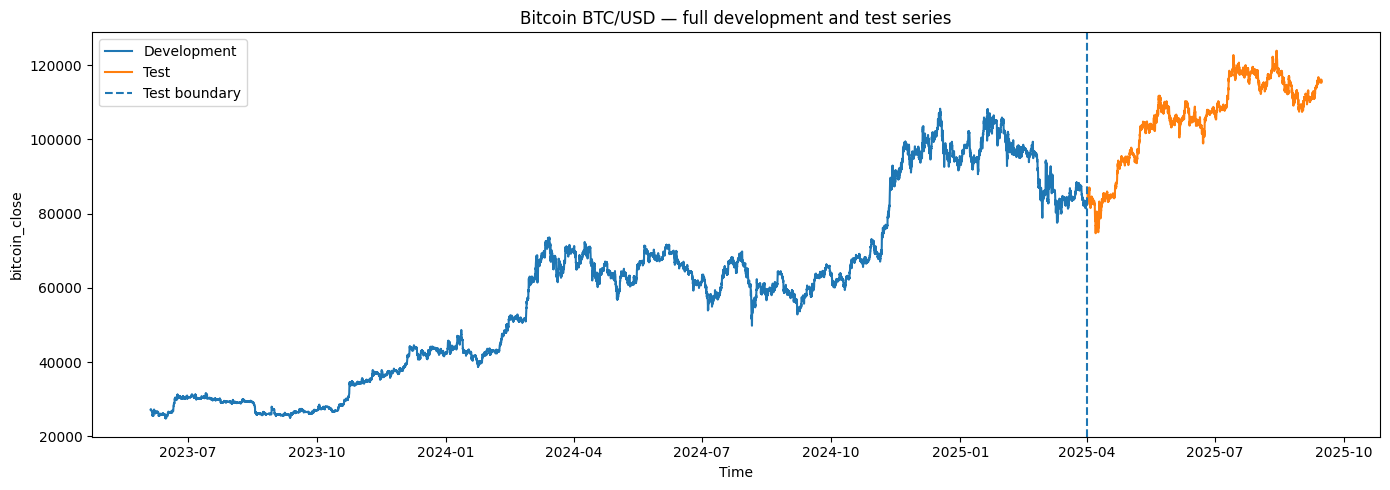

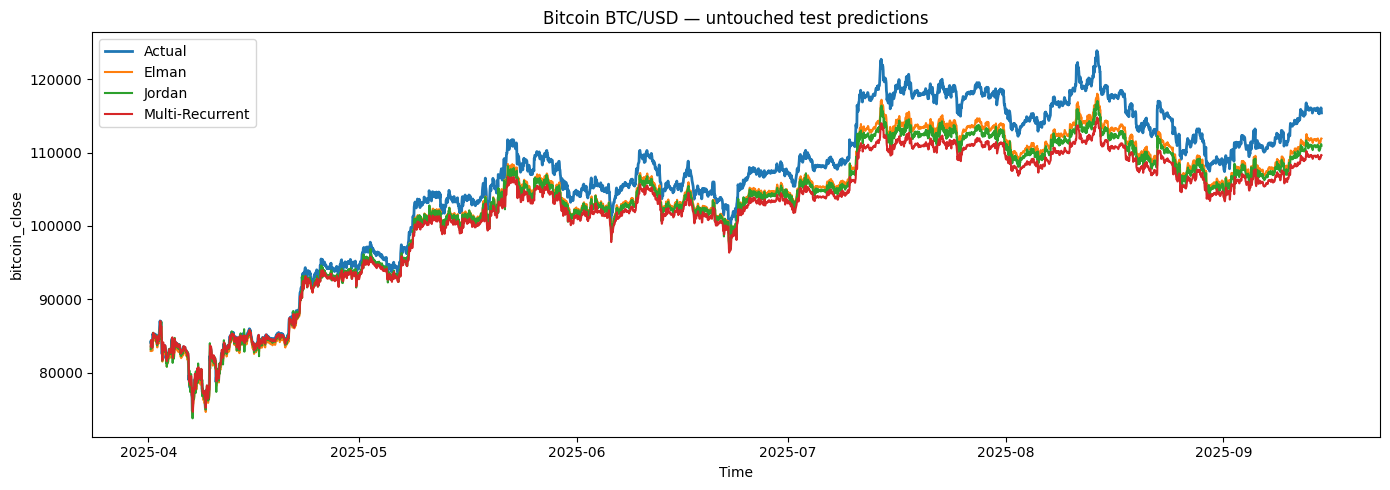

In [91]:
ds2_final_table = train_and_evaluate_dataset("ds2")

plot_full_series("ds2")
plot_test_predictions("ds2")


## Dataset 3 — Beijing Temperature

Train all three frozen RNN configurations on the full development partition, evaluate them on the untouched test partition, print the test metrics, select the lowest-test-RMSE RNN for reporting, and plot the full series plus the three test prediction traces.


FINAL TRAINING: ds3 — Beijing Temperature

ELMAN | window=360 | hidden=32 | lr=0.0001 | wd=0.0 | CV best epochs=[np.int64(74), np.int64(73), np.int64(70), np.int64(58)] | final epochs=72
[2026-09-25 14:48:04] final epoch 1/72 | train_scaled_mse=0.351834
[2026-09-25 14:53:10] final epoch 7/72 | train_scaled_mse=0.0359509
[2026-09-25 14:56:57] final epoch 14/72 | train_scaled_mse=0.0233967
[2026-09-25 15:00:20] final epoch 21/72 | train_scaled_mse=0.0174658
[2026-09-25 15:03:42] final epoch 28/72 | train_scaled_mse=0.0142694
[2026-09-25 15:07:20] final epoch 35/72 | train_scaled_mse=0.0129228
[2026-09-25 15:11:55] final epoch 42/72 | train_scaled_mse=0.0123919
[2026-09-25 15:16:43] final epoch 49/72 | train_scaled_mse=0.0121623
[2026-09-25 15:20:28] final epoch 56/72 | train_scaled_mse=0.0120351
[2026-09-25 15:24:48] final epoch 63/72 | train_scaled_mse=0.0119379
[2026-09-25 15:28:47] final epoch 70/72 | train_scaled_mse=0.01185
[2026-09-25 15:29:43] final epoch 72/72 | train_scaled_mse

,model,test_rmse,test_mae,test_mase,test_pearson_r,test_r2,test_mean_error,runtime_seconds
0,elman,1.355297,0.988862,0.575993,0.993180,0.986397,-0.031898,2572.435470
1,multi,1.645562,1.271363,0.740544,0.991627,0.979946,-0.473626,5046.840057
2,jordan,1.976216,1.476562,0.860068,0.985440,0.971077,0.045685,17.583559
3,persistence,2.362268,1.801050,1.049076,0.979332,0.958673,0.002738,0.000000


Best RNN on the untouched test set: elman (RMSE=1.3553)
Best overall including persistence: elman (RMSE=1.3553)


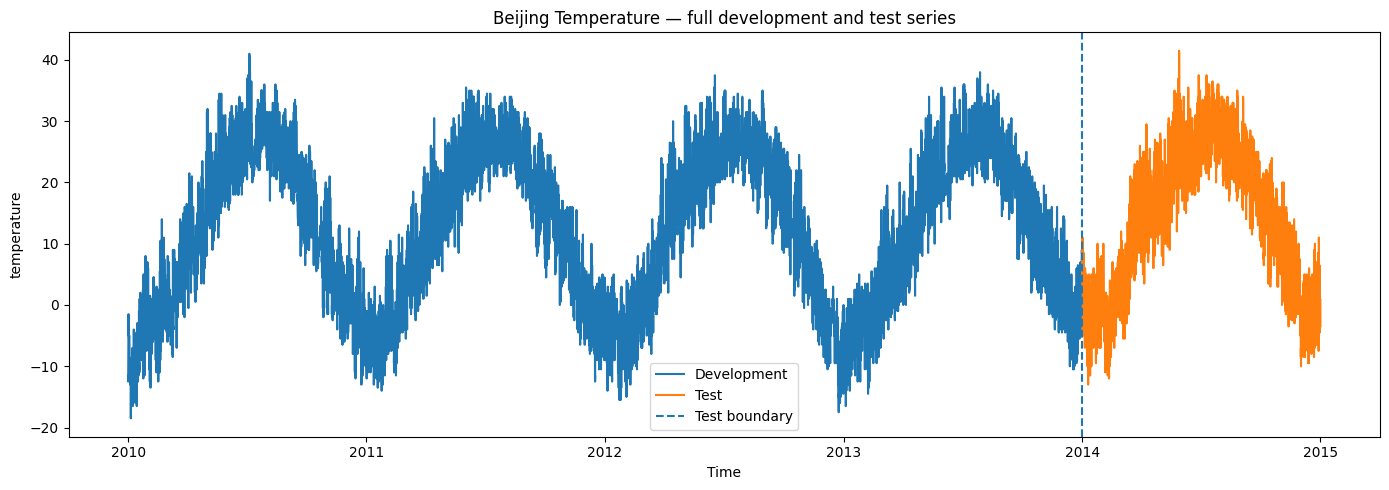

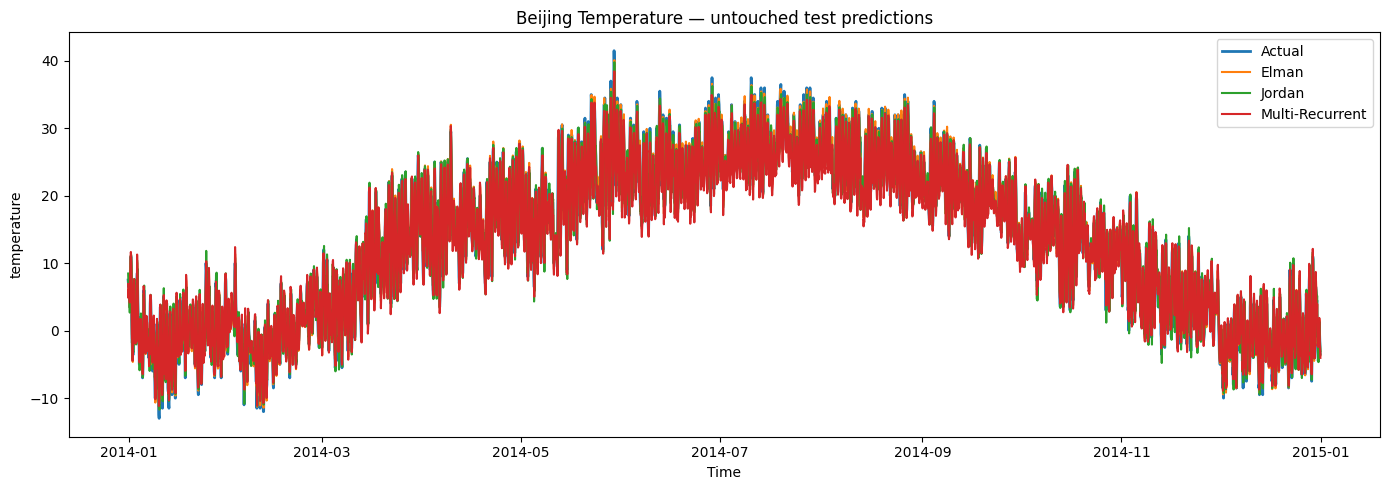

In [92]:
ds3_final_table = train_and_evaluate_dataset("ds3")

plot_full_series("ds3")
plot_test_predictions("ds3")


## Dataset 4 — Mauna Loa CO₂


FINAL TRAINING: ds4 — Mauna Loa CO₂

ELMAN | window=730 | hidden=64 | lr=0.001 | wd=0.0001 | CV best epochs=[np.int64(23), np.int64(16), np.int64(70), np.int64(34)] | final epochs=29
[2026-09-25 16:57:34] final epoch 1/29 | train_scaled_mse=0.0292426
[2026-09-25 16:58:27] final epoch 2/29 | train_scaled_mse=0.00199355
[2026-09-25 17:00:14] final epoch 4/29 | train_scaled_mse=0.00115065
[2026-09-25 17:01:55] final epoch 6/29 | train_scaled_mse=0.000959047
[2026-09-25 17:03:35] final epoch 8/29 | train_scaled_mse=0.00084188
[2026-09-25 17:05:24] final epoch 10/29 | train_scaled_mse=0.0010401
[2026-09-25 17:07:29] final epoch 12/29 | train_scaled_mse=0.000967132
[2026-09-25 17:09:54] final epoch 14/29 | train_scaled_mse=0.0009143
[2026-09-25 17:13:08] final epoch 16/29 | train_scaled_mse=0.000876903
[2026-09-25 17:17:03] final epoch 18/29 | train_scaled_mse=0.000853395
[2026-09-25 17:21:01] final epoch 20/29 | train_scaled_mse=0.000841579
[2026-09-25 17:25:05] final epoch 22/29 | train_s

,model,test_rmse,test_mae,test_mase,test_pearson_r,test_r2,test_mean_error,runtime_seconds
0,persistence,0.600369,0.394243,1.226507,0.996614,0.993227,-0.006068,0.000000
1,jordan,2.215897,1.720368,5.352144,0.994705,0.907733,-1.642103,2492.268218
2,multi,2.315433,1.763511,5.486363,0.995061,0.899258,-1.600542,5273.718877
3,elman,2.679105,2.042552,6.354473,0.994475,0.865126,-1.894003,2599.442687


Best RNN on the untouched test set: jordan (RMSE=2.2159)
Best overall including persistence: persistence (RMSE=0.600369)


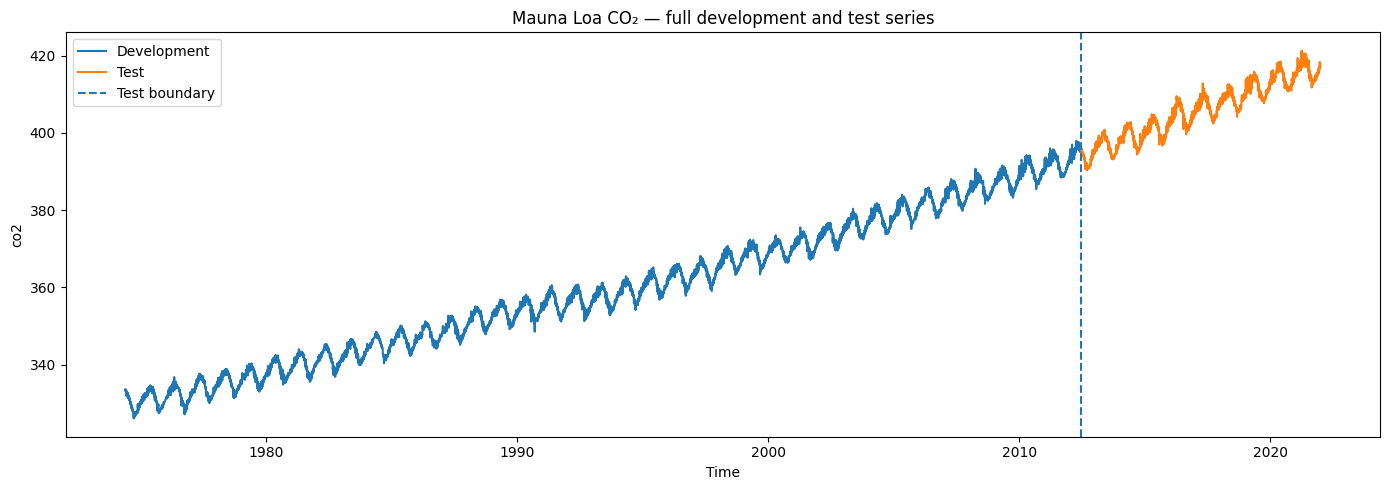

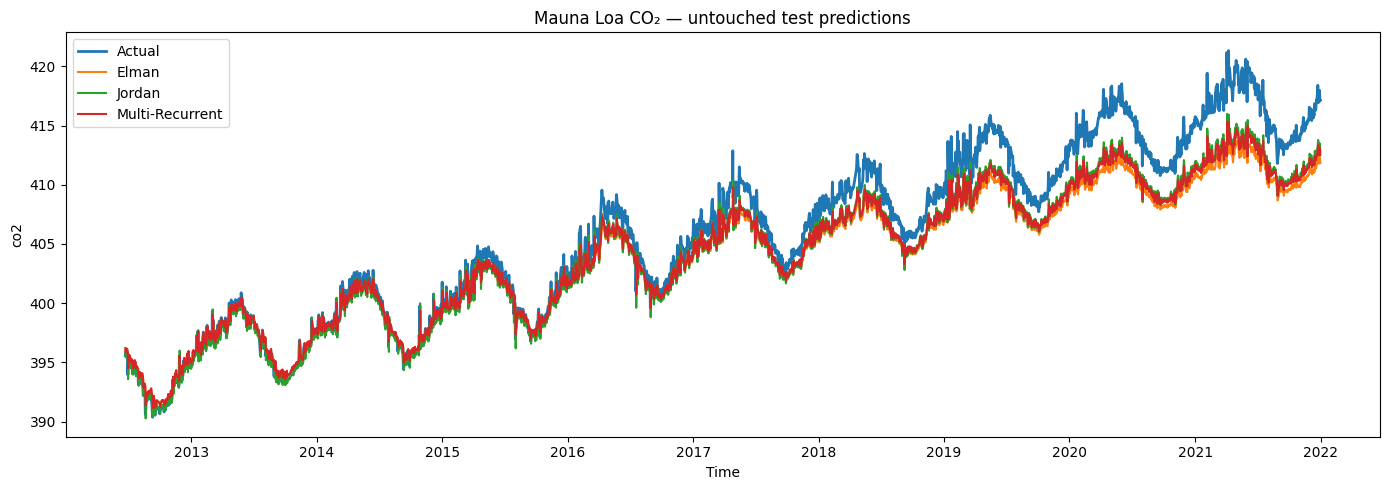

In [93]:
ds4_final_table = train_and_evaluate_dataset("ds4")

plot_full_series("ds4")
plot_test_predictions("ds4")


## Dataset 5 — Jena Wind Velocity



FINAL TRAINING: ds5 — Jena Wind Velocity

ELMAN | window=168 | hidden=64 | lr=0.001 | wd=0.0 | CV best epochs=[np.int64(7), np.int64(14), np.int64(18), np.int64(14)] | final epochs=14
[2026-09-25 19:50:00] final epoch 1/14 | train_scaled_mse=0.296396
[2026-09-25 19:50:10] final epoch 2/14 | train_scaled_mse=0.226989
[2026-09-25 19:50:21] final epoch 3/14 | train_scaled_mse=0.223039
[2026-09-25 19:50:31] final epoch 4/14 | train_scaled_mse=0.225628
[2026-09-25 19:50:43] final epoch 5/14 | train_scaled_mse=0.22303
[2026-09-25 19:50:53] final epoch 6/14 | train_scaled_mse=0.228274
[2026-09-25 19:51:04] final epoch 7/14 | train_scaled_mse=0.264245
[2026-09-25 19:51:15] final epoch 8/14 | train_scaled_mse=0.240899
[2026-09-25 19:51:25] final epoch 9/14 | train_scaled_mse=0.251007
[2026-09-25 19:51:36] final epoch 10/14 | train_scaled_mse=0.240562
[2026-09-25 19:51:47] final epoch 11/14 | train_scaled_mse=0.249509
[2026-09-25 19:51:58] final epoch 12/14 | train_scaled_mse=0.241112
[2026-09-

,model,test_rmse,test_mae,test_mase,test_pearson_r,test_r2,test_mean_error,runtime_seconds
0,jordan,0.691804,0.490006,0.988666,0.894291,0.799664,0.006965,26.579702
1,multi,0.696028,0.499666,1.008155,0.895079,0.797211,0.001129,203.110363
2,elman,0.702347,0.501611,1.012080,0.894430,0.793512,-0.025027,156.311724
3,persistence,0.706964,0.493344,0.995400,0.895391,0.790788,0.000091,0.000000


Best RNN on the untouched test set: jordan (RMSE=0.691804)
Best overall including persistence: jordan (RMSE=0.691804)


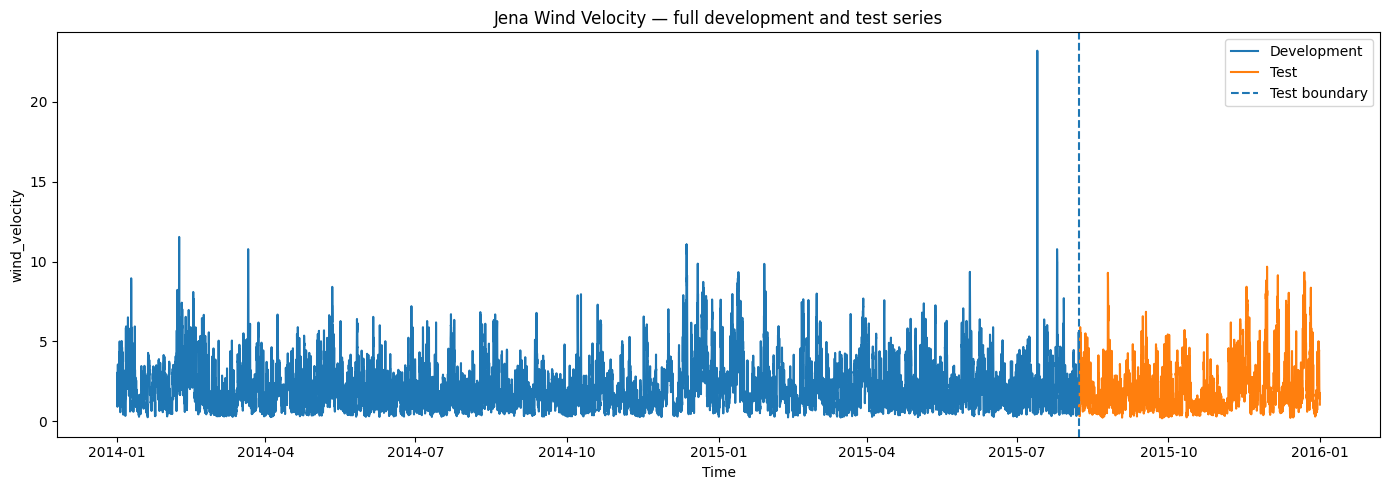

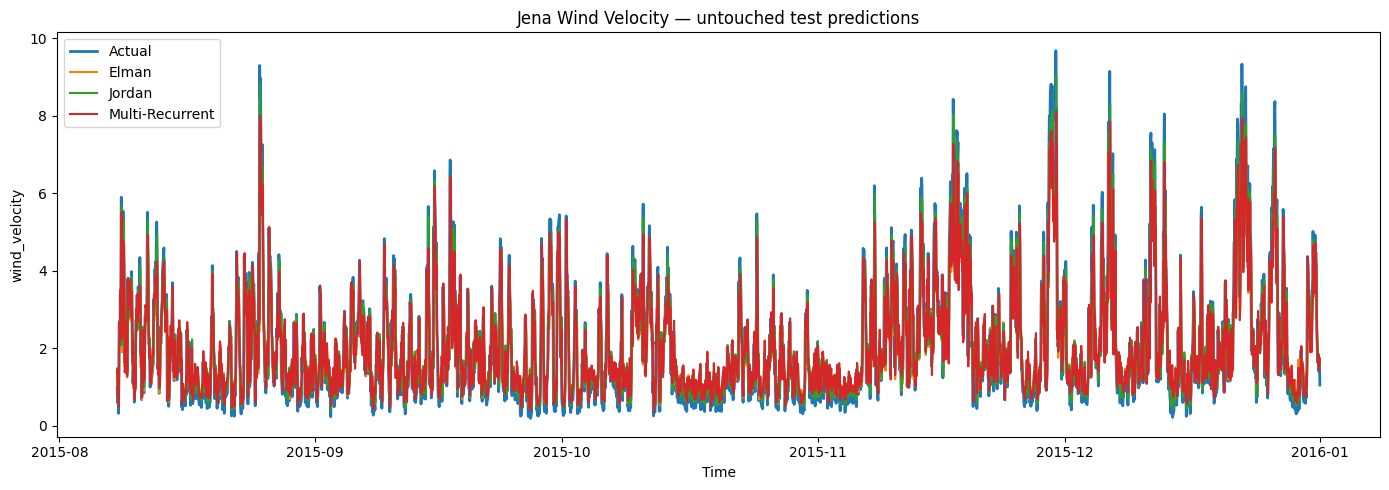

In [94]:
ds5_final_table = train_and_evaluate_dataset("ds5")

plot_full_series("ds5")
plot_test_predictions("ds5")


# Final test summary

In [1]:
final_results_df = pd.DataFrame(final_test_results)

final_results_df.to_csv(
    FINAL_DIR / "final_test_results.csv",
    index=False,
)

epoch_choices_df = pd.DataFrame(
    final_epoch_choices
)

epoch_choices_df.to_csv(
    FINAL_DIR / "final_epoch_choices.csv",
    index=False,
)

print("Final epoch choices derived only from CV:")
display(
    epoch_choices_df[
        [
            "dataset",
            "architecture",
            "window_size",
            "hidden_size",
            "learning_rate",
            "weight_decay",
            "cv_best_epochs",
            "final_epochs",
            "cv_mean_val_rmse",
            "cv_std_val_rmse",
        ]
    ]
)

print("\nAll final untouched-test metrics:")
display_columns = [
    "dataset",
    "architecture",
    "test_rmse",
    "test_mae",
    "test_mase",
    "test_pearson_r",
    "test_r2",
    "test_mean_error",
    "test_median_absolute_error",
    "runtime_seconds",
]

display(
    final_results_df[
        display_columns
    ].sort_values(
        ["dataset", "test_rmse"]
    ).reset_index(drop=True)
)

rnn_results = final_results_df[
    final_results_df["architecture"].isin(
        ARCHITECTURES
    )
].copy()

rmse_table = (
    rnn_results.pivot(
        index="dataset",
        columns="architecture",
        values="test_rmse",
    )
    .reindex(
        columns=ARCHITECTURES
    )
)

winner_rows = (
    rnn_results.loc[
        rnn_results.groupby("dataset")[
            "test_rmse"
        ].idxmin()
    ][
        [
            "dataset",
            "architecture",
            "test_rmse",
        ]
    ]
    .set_index("dataset")
)

rmse_summary = rmse_table.copy()
rmse_summary["winning_rnn"] = (
    winner_rows["architecture"]
)
rmse_summary["winning_rmse"] = (
    winner_rows["test_rmse"]
)

print(
    "\nTest RMSE comparison and winning RNN "
    "for each dataset:"
)

display(rmse_summary)

rmse_summary.to_csv(
    FINAL_DIR / "test_rmse_summary.csv"
)

persistence_results = (
    final_results_df[
        final_results_df["architecture"]
        == "persistence"
    ][
        [
            "dataset",
            "test_rmse",
            "test_mae",
            "test_mase",
            "test_r2",
        ]
    ]
    .rename(
        columns={
            "test_rmse": "persistence_rmse",
            "test_mae": "persistence_mae",
            "test_mase": "persistence_mase",
            "test_r2": "persistence_r2",
        }
    )
)

best_rnn_results = winner_rows.reset_index()

baseline_comparison = best_rnn_results.merge(
    persistence_results,
    on="dataset",
    how="left",
)

baseline_comparison["rnn_beats_persistence_rmse"] = (
    baseline_comparison["test_rmse"]
    < baseline_comparison["persistence_rmse"]
)

print(
    "\nBest RNN versus persistence on the "
    "untouched test set:"
)

display(baseline_comparison)

baseline_comparison.to_csv(
    FINAL_DIR / "best_rnn_vs_persistence.csv",
    index=False,
)

print(
    "\nSaved report-ready outputs to:",
    FINAL_DIR.resolve(),
)

NameError: name 'pd' is not defined